# Boston CityScore EDA: From Raw XLSX to Mayor-Facing Diagnostics

This notebook documents the full analytical workflow used in the project:
- load and inspect 4 daily source files
- clean and standardize the data
- engineer service-performance metrics
- aggregate into executive-level diagnostics
- visualize trends, strengths, risks, and data quality
- map the analysis layer to the backend/dashboard architecture

The objective is to make the end-to-end methodology transparent and reproducible.


## Notebook Roadmap

1. Setup and reproducibility
2. Data ingestion and structure audit
3. Cleaning pipeline and assumptions
4. Core modeling tables
5. Derived metrics and classification logic
6. Portfolio health and executive aggregations
7. Visualization suite
8. Architecture and API mapping
9. Findings, caveats, and next iterations
10. Validation checks


In [15]:
# Core numerical and data libraries
import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import seaborn as sns

# Reproducibility and notebook display controls
np.random.seed(42)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

# Visual style aligned with project palette
sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "#FBF5DD"
plt.rcParams["axes.facecolor"] = "#FFFDF6"
plt.rcParams["axes.edgecolor"] = "#0D530E"
plt.rcParams["grid.color"] = "#DAD8BE"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"


In [16]:
# Locate project root in a robust way so the notebook can run from root or subfolders.
CURRENT_DIR = Path.cwd()
CANDIDATES = [CURRENT_DIR, CURRENT_DIR.parent, CURRENT_DIR.parent.parent]
PROJECT_ROOT = None

for candidate in CANDIDATES:
    if (candidate / "Excel").exists() or (candidate / "Codes").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing Excel/ or Codes/.")

# Raw data can be in Excel/ (local dev) or Codes/Excel/ (deployment-friendly layout).
if (PROJECT_ROOT / "Excel").exists():
    DATA_DIR = PROJECT_ROOT / "Excel"
elif (PROJECT_ROOT / "Codes" / "Excel").exists():
    DATA_DIR = PROJECT_ROOT / "Codes" / "Excel"
else:
    raise FileNotFoundError("Could not locate source data folder: expected Excel/ or Codes/Excel/.")

CLEANED_DIR = PROJECT_ROOT / "cleaned csv"
AGG_DIR = PROJECT_ROOT / "aggregated data"

# Add backend code path to import shared metric catalog utilities.
CODE_DIR = PROJECT_ROOT / "Codes"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cityscore_backend.metric_catalog import (
    SERVICE_AREA_ORDER,
    get_metric_metadata,
    normalize_metric_name,
)

SOURCE_FILES = {
    "current_full_metrics": DATA_DIR / "CityScore_Full_Metric_list.xlsx",
    "current_summary": DATA_DIR / "CityScore_Summary.xlsx",
    "historical_city_agg": DATA_DIR / "rpt_city_score_agg_v.csv.xlsx",
    "historical_metric_summary": DATA_DIR / "rpt_city_score_summary.csv.xlsx",
}

# Required-file assertion from the test plan.
missing = [str(path) for path in SOURCE_FILES.values() if not path.exists()]
assert not missing, f"Missing required source files: {missing}"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Cleaned directory:", CLEANED_DIR)
print("Aggregated directory:", AGG_DIR)
print("\nSource files:")
for key, path in SOURCE_FILES.items():
    print(f"- {key}: {path.name}")


Project root: /Users/ameyasutar1gmail.com/Desktop/IIMA/python/Boston Home Assignment
Data directory: /Users/ameyasutar1gmail.com/Desktop/IIMA/python/Boston Home Assignment/Excel
Cleaned directory: /Users/ameyasutar1gmail.com/Desktop/IIMA/python/Boston Home Assignment/cleaned csv
Aggregated directory: /Users/ameyasutar1gmail.com/Desktop/IIMA/python/Boston Home Assignment/aggregated data

Source files:
- current_full_metrics: CityScore_Full_Metric_list.xlsx
- current_summary: CityScore_Summary.xlsx
- historical_city_agg: rpt_city_score_agg_v.csv.xlsx
- historical_metric_summary: rpt_city_score_summary.csv.xlsx


In [17]:
# Helpful timestamp context: file modification dates and data-as-of timestamps.
source_context = []
for source_name, source_path in SOURCE_FILES.items():
    source_context.append({
        "source_name": source_name,
        "file_name": source_path.name,
        "file_size_kb": round(source_path.stat().st_size / 1024, 2),
        "file_modified": pd.to_datetime(source_path.stat().st_mtime, unit="s"),
    })

source_context_df = pd.DataFrame(source_context).sort_values("source_name").reset_index(drop=True)
source_context_df


,source_name,file_name,file_size_kb,file_modified
0,current_full_metrics,CityScore_Full_Metric_list.xlsx,22.81,2026-05-24 05:32:45.243513346
1,current_summary,CityScore_Summary.xlsx,11.94,2026-05-24 05:32:49.623235703
2,historical_city_agg,rpt_city_score_agg_v.csv.xlsx,51.75,2026-05-24 05:32:52.782652140
3,historical_metric_summary,rpt_city_score_summary.csv.xlsx,2461.91,2026-05-24 05:32:49.152196407


## 1) Data Ingestion and Structure Audit

This section loads all four source files and inspects their structure before any transformation.


In [18]:
# Load all raw datasets exactly once and keep them in a dictionary for traceability.
raw_frames = {name: pd.read_excel(path) for name, path in SOURCE_FILES.items()}

# Quick shape overview for ingestion validation.
raw_shape_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": frame.shape[0],
        "columns": frame.shape[1],
    }
    for name, frame in raw_frames.items()
]).sort_values("dataset").reset_index(drop=True)

raw_shape_summary

## We have successfully ingested all source datasets. Next, we will perform detailed data cleaning and transformation to prepare for analysis and visualization. This includes:
# - Standardizing metric names and categories using the metric catalog.
# - Handling missing values and ensuring consistent data types.
# - Creating derived fields for time-based analysis (e.g., year, month).
# - Validating data integrity and consistency across datasets.


,dataset,rows,columns
0,current_full_metrics,115,17
1,current_summary,23,8
2,historical_city_agg,844,6
3,historical_metric_summary,18235,23


In [19]:
# Standard profile function to inspect each raw dataset with consistent diagnostics.
def profile_raw_frame(frame: pd.DataFrame, name: str) -> dict:
    profile = {
        "dataset": name,
        "rows": int(frame.shape[0]),
        "columns": int(frame.shape[1]),
        "null_cells": int(frame.isna().sum().sum()),
        "all_null_columns": int((frame.isna().all()).sum()),
        "duplicate_rows": int(frame.duplicated().sum()),
    }

    # If metric-like columns exist, compute unique metric counts.
    metric_candidates = [
        col for col in frame.columns
        if str(col).strip().lower() in {"metric_name", "cty_scr_name"}
    ]
    if metric_candidates:
        metric_col = metric_candidates[0]
        profile["unique_metrics"] = int(frame[metric_col].astype(str).nunique())
    else:
        profile["unique_metrics"] = np.nan

    # If date/timestamp-like columns exist, summarize temporal range.
    date_candidates = [
        col for col in frame.columns
        if any(token in str(col).lower() for token in ["date", "ts", "timestamp"])
    ]
    if date_candidates:
        col = date_candidates[0]
        parsed = pd.to_datetime(frame[col], errors="coerce")
        profile["primary_date_column"] = col
        profile["min_date_raw_parse"] = parsed.min()
        profile["max_date_raw_parse"] = parsed.max()
    else:
        profile["primary_date_column"] = None
        profile["min_date_raw_parse"] = pd.NaT
        profile["max_date_raw_parse"] = pd.NaT

    return profile

raw_profiles = pd.DataFrame([profile_raw_frame(df, name) for name, df in raw_frames.items()])
raw_profiles.sort_values("dataset").reset_index(drop=True)


,dataset,rows,columns,null_cells,all_null_columns,duplicate_rows,unique_metrics,primary_date_column,min_date_raw_parse,max_date_raw_parse
0,current_full_metrics,115,17,394,0,0,23.0,score_calculated_ts,2026-03-25 11:24:48.813,2026-05-16 07:20:18.724
1,current_summary,23,8,29,0,0,23.0,score_calculated_ts,2026-05-16 07:20:14.695,2026-05-16 07:20:18.724
2,historical_city_agg,844,6,0,0,0,NaN,ETL_LOAD_DATE,2016-01-15 00:00:00.000,2019-04-12 00:00:00.000
3,historical_metric_summary,18235,23,96433,0,0,22.0,ETL_LOAD_DATE,2016-01-15 00:00:00.000,2019-04-11 00:00:00.000


In [20]:
# Compare metric coverage across current and historical sources before normalization.
def metric_set_from_raw(frame: pd.DataFrame, candidates: list[str], frame_name: str) -> set[str]:
    """Return a normalized metric-name set using case-insensitive column matching."""
    lookup = {str(col).strip().lower(): col for col in frame.columns}
    chosen_col = None
    for candidate in candidates:
        key = candidate.strip().lower()
        if key in lookup:
            chosen_col = lookup[key]
            break
    if chosen_col is None:
        raise KeyError(
            f"No metric column found in {frame_name}. Tried {candidates}. "
            f"Available columns: {list(frame.columns)}"
        )
    return set(frame[chosen_col].dropna().astype(str).str.strip().str.upper())

full_metric_set = metric_set_from_raw(raw_frames["current_full_metrics"], ["metric_name", "cty_scr_name"], "current_full_metrics")
summary_metric_set = metric_set_from_raw(raw_frames["current_summary"], ["metric_name", "cty_scr_name"], "current_summary")
history_metric_set = metric_set_from_raw(raw_frames["historical_metric_summary"], ["cty_scr_name", "metric_name"], "historical_metric_summary")

coverage_table = pd.DataFrame([
    {"set": "current_full_metrics", "metric_count": len(full_metric_set)},
    {"set": "current_summary", "metric_count": len(summary_metric_set)},
    {"set": "historical_metric_summary", "metric_count": len(history_metric_set)},
    {"set": "intersection(full, summary)", "metric_count": len(full_metric_set & summary_metric_set)},
    {"set": "intersection(full, history)", "metric_count": len(full_metric_set & history_metric_set)},
    {"set": "union(all)", "metric_count": len(full_metric_set | summary_metric_set | history_metric_set)},
])

coverage_table


,set,metric_count
0,current_full_metrics,23
1,current_summary,23
2,historical_metric_summary,22
3,"intersection(full, summary)",23
4,"intersection(full, history)",21
5,union(all),24


## 2) Cleaning Pipeline and Assumptions

Cleaning rules are intentionally explicit and aligned with the backend pipeline:
- normalize column names
- trim text and standardize empty markers
- remove fully empty rows/columns
- convert Excel serial dates and parse timestamp strings
- coerce numeric fields where appropriate
- normalize metric names and aliases
- sort and deduplicate


In [21]:
# Core reusable cleaning helpers (aligned to backend logic).
def snake_case_columns(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned.columns = (
        cleaned.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("%", "pct", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.replace(r"[^a-z0-9_]+", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return cleaned


def strip_text_values(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    object_cols = cleaned.select_dtypes(include=["object", "string"]).columns
    for col in object_cols:
        cleaned[col] = cleaned[col].astype("string").str.strip()
        cleaned[col] = cleaned[col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    return cleaned


def drop_empty_rows_and_columns(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.dropna(how="all").copy()
    cleaned = cleaned.dropna(axis=1, how="all")
    return cleaned


def convert_excel_serial_dates(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    cleaned = df.copy()
    for col in columns:
        if col not in cleaned.columns:
            continue
        numeric_values = pd.to_numeric(cleaned[col], errors="coerce")
        excel_dates = pd.to_datetime(numeric_values, unit="D", origin="1899-12-30", errors="coerce")
        parsed_dates = pd.to_datetime(cleaned[col], errors="coerce")
        cleaned[col] = excel_dates.where(excel_dates.notna(), parsed_dates)
    return cleaned


def coerce_numeric_columns(df: pd.DataFrame, skip_columns: set[str]) -> pd.DataFrame:
    cleaned = df.copy()
    for col in cleaned.columns:
        if col in skip_columns or pd.api.types.is_datetime64_any_dtype(cleaned[col]):
            continue
        numeric_values = pd.to_numeric(cleaned[col], errors="coerce")
        if numeric_values.notna().sum() > 0:
            cleaned[col] = numeric_values
    return cleaned


def base_clean(df: pd.DataFrame) -> pd.DataFrame:
    # Standard base cleaning stack used before dataset-specific rules.
    cleaned = snake_case_columns(df)
    cleaned = strip_text_values(cleaned)
    cleaned = drop_empty_rows_and_columns(cleaned)
    return cleaned


In [22]:
# Dataset-specific cleaning functions.
def clean_current_full_metrics(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = base_clean(df)
    cleaned = convert_excel_serial_dates(cleaned, ["score_calculated_ts"])
    cleaned["metric_name"] = cleaned["metric_name"].map(normalize_metric_name)
    cleaned = coerce_numeric_columns(
        cleaned,
        skip_columns={"metric_name", "metric_logic", "score_calculated_ts", "latest_score_flag"},
    )
    cleaned["latest_score_flag"] = pd.to_numeric(cleaned["latest_score_flag"], errors="coerce").fillna(0).astype(int)
    cleaned = cleaned.drop_duplicates().sort_values(["metric_name", "score_calculated_ts"]).reset_index(drop=True)
    return cleaned


def clean_current_summary(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = base_clean(df)
    cleaned = convert_excel_serial_dates(cleaned, ["score_calculated_ts", "score_final_table_ts"])
    cleaned["metric_name"] = cleaned["metric_name"].map(normalize_metric_name)
    cleaned = coerce_numeric_columns(
        cleaned,
        skip_columns={"metric_name", "score_calculated_ts", "score_final_table_ts", "score_day_name"},
    )
    cleaned = cleaned.drop_duplicates().sort_values(["metric_name", "score_final_table_ts"]).reset_index(drop=True)
    return cleaned


def clean_historical_city_agg(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = base_clean(df)
    cleaned = convert_excel_serial_dates(cleaned, ["etl_load_date"])
    cleaned = coerce_numeric_columns(
        cleaned,
        skip_columns={"etl_load_date", "etl_load_is_active_flag"},
    )
    cleaned = cleaned.drop_duplicates().sort_values("etl_load_date").reset_index(drop=True)
    return cleaned


def clean_historical_metric_summary(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = base_clean(df)
    cleaned = convert_excel_serial_dates(cleaned, ["etl_load_date"])
    cleaned["cty_scr_name"] = cleaned["cty_scr_name"].map(normalize_metric_name)
    cleaned = coerce_numeric_columns(
        cleaned,
        skip_columns={
            "cty_scr_name",
            "etl_load_date",
            "etl_load_is_active_flag",
            "cty_scr_open_data_source",
            "cty_scr_metric_type",
            "cty_scr_day_name",
        },
    )
    cleaned = cleaned.drop_duplicates().sort_values(["cty_scr_name", "etl_load_date"]).reset_index(drop=True)
    return cleaned


In [23]:
# Apply cleaning pipeline.
cleaned_frames = {
    "current_full_metrics": clean_current_full_metrics(raw_frames["current_full_metrics"]),
    "current_summary": clean_current_summary(raw_frames["current_summary"]),
    "historical_city_agg": clean_historical_city_agg(raw_frames["historical_city_agg"]),
    "historical_metric_summary": clean_historical_metric_summary(raw_frames["historical_metric_summary"]),
}

clean_shape_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": frame.shape[0],
        "columns": frame.shape[1],
        "null_cells": int(frame.isna().sum().sum()),
        "duplicate_rows": int(frame.duplicated().sum()),
    }
    for name, frame in cleaned_frames.items()
]).sort_values("dataset").reset_index(drop=True)

clean_shape_summary


,dataset,rows,columns,null_cells,duplicate_rows
0,current_full_metrics,115,17,394,0
1,current_summary,23,8,29,0
2,historical_city_agg,844,6,0,0
3,historical_metric_summary,18235,23,96433,0


In [24]:
# Date coverage after cleaning.
def date_span(frame: pd.DataFrame, date_col: str) -> tuple[pd.Timestamp, pd.Timestamp, int]:
    if date_col not in frame.columns:
        return pd.NaT, pd.NaT, 0
    series = pd.to_datetime(frame[date_col], errors="coerce")
    return series.min(), series.max(), int(series.dt.normalize().nunique())

coverage_post_clean = pd.DataFrame([
    {
        "dataset": "current_full_metrics",
        "date_column": "score_calculated_ts",
        "min_date": date_span(cleaned_frames["current_full_metrics"], "score_calculated_ts")[0],
        "max_date": date_span(cleaned_frames["current_full_metrics"], "score_calculated_ts")[1],
        "unique_dates": date_span(cleaned_frames["current_full_metrics"], "score_calculated_ts")[2],
    },
    {
        "dataset": "current_summary",
        "date_column": "score_final_table_ts",
        "min_date": date_span(cleaned_frames["current_summary"], "score_final_table_ts")[0],
        "max_date": date_span(cleaned_frames["current_summary"], "score_final_table_ts")[1],
        "unique_dates": date_span(cleaned_frames["current_summary"], "score_final_table_ts")[2],
    },
    {
        "dataset": "historical_city_agg",
        "date_column": "etl_load_date",
        "min_date": date_span(cleaned_frames["historical_city_agg"], "etl_load_date")[0],
        "max_date": date_span(cleaned_frames["historical_city_agg"], "etl_load_date")[1],
        "unique_dates": date_span(cleaned_frames["historical_city_agg"], "etl_load_date")[2],
    },
    {
        "dataset": "historical_metric_summary",
        "date_column": "etl_load_date",
        "min_date": date_span(cleaned_frames["historical_metric_summary"], "etl_load_date")[0],
        "max_date": date_span(cleaned_frames["historical_metric_summary"], "etl_load_date")[1],
        "unique_dates": date_span(cleaned_frames["historical_metric_summary"], "etl_load_date")[2],
    },
])

coverage_post_clean


,dataset,date_column,min_date,max_date,unique_dates
0,current_full_metrics,score_calculated_ts,2026-03-25 11:24:48.813,2026-05-16 07:20:18.724,5
1,current_summary,score_final_table_ts,2026-05-16 08:45:36.567,2026-05-16 08:45:36.567,1
2,historical_city_agg,etl_load_date,2016-01-15 00:00:00.000,2019-04-12 00:00:00.000,844
3,historical_metric_summary,etl_load_date,2016-01-15 00:00:00.000,2019-04-11 00:00:00.000,843


## 3) Core Modeling Tables

We now construct the three core analytical tables:
- `metric_master`: one row per metric with semantic metadata
- `metric_history_long`: one row per metric x period x date
- `city_score_history`: one row per period x date


In [25]:
# Build metric master from all available metric names.
all_metrics = set(cleaned_frames["current_full_metrics"]["metric_name"].dropna().tolist())
all_metrics.update(cleaned_frames["current_summary"]["metric_name"].dropna().tolist())
all_metrics.update(cleaned_frames["historical_metric_summary"]["cty_scr_name"].dropna().tolist())

latest_detail_lookup = (
    cleaned_frames["current_full_metrics"]
    .sort_values(["metric_name", "latest_score_flag", "score_calculated_ts"])
    .groupby("metric_name", as_index=False)
    .tail(1)
    .set_index("metric_name")
)

master_rows = []
for metric_name in sorted(all_metrics):
    metadata = get_metric_metadata(metric_name)
    latest_row = latest_detail_lookup.loc[metric_name] if metric_name in latest_detail_lookup.index else None
    master_rows.append({
        "metric_name": metric_name,
        "display_name": metadata["display_name"],
        "service_area": metadata["service_area"],
        "owner_department": metadata["owner_department"],
        "cadence": metadata["cadence"],
        "definition": metadata["definition"],
        "default_metric_logic": latest_row.get("metric_logic") if latest_row is not None else None,
        "default_target": float(latest_row.get("target")) if latest_row is not None and pd.notna(latest_row.get("target")) else np.nan,
        "has_current_detail": metric_name in set(cleaned_frames["current_full_metrics"]["metric_name"].dropna()),
        "has_current_summary": metric_name in set(cleaned_frames["current_summary"]["metric_name"].dropna()),
        "has_history": metric_name in set(cleaned_frames["historical_metric_summary"]["cty_scr_name"].dropna()),
    })

metric_master = pd.DataFrame(master_rows)
metric_master["service_area_order"] = metric_master["service_area"].map(lambda x: SERVICE_AREA_ORDER.index(x) if x in SERVICE_AREA_ORDER else len(SERVICE_AREA_ORDER))
metric_master = metric_master.sort_values(["service_area_order", "display_name"]).reset_index(drop=True)

metric_master.head(10)


,metric_name,display_name,service_area,owner_department,cadence,definition,default_metric_logic,default_target,has_current_detail,has_current_summary,has_history,service_area_order
0,BFD INCIDENTS,BFD Incidents,Public Safety,Boston Fire Department,weekday,Fire-related incidents versus the historical a...,historical_average / current_average,NaN,True,True,True,0
1,BFD RESPONSE TIME,BFD Response Time,Public Safety,Boston Fire Department,weekday,Percent of fire responses arriving within 4 mi...,sum(numerator_value)/sum(denominator_value)/ta...,0.90,True,True,True,0
2,EMS INCIDENTS,EMS Incidents,Public Safety,Emergency Medical Services,weekday,EMS incident volume versus the historical aver...,NaN,NaN,False,False,True,0
3,EMS RESPONSE TIME,EMS Response Time,Public Safety,Emergency Medical Services,weekday,Median priority-1 EMS response time against a ...,target / median,6.00,True,True,True,0
4,HOMICIDES (TREND),Homicides,Public Safety,Boston Police Department,weekday,Homicide trend versus historical average. Scor...,historical_average / current_average,NaN,True,True,True,0
5,PART 1 CRIMES,Part 1 Crimes,Public Safety,Boston Police Department,weekday,"Serious FBI index crimes excluding homicides, ...",historical_average / current_average,NaN,True,True,True,0
6,SHOOTINGS (TREND),Shootings,Public Safety,Boston Police Department,weekday,Non-fatal shootings versus the historical aver...,historical_average / current_average,NaN,True,True,True,0
7,STABBINGS (TREND),Stabbings,Public Safety,Boston Police Department,weekday,Non-fatal stabbings versus the historical aver...,historical_average / current_average,NaN,True,True,True,0
8,311 CALL CENTER PERFORMANCE,311 Call Center Performance,Resident Experience,311 Constituent Services,weekday,Percent of 311 calls answered within 30 second...,sum(numerator_value)/sum(denominator_value)/ta...,0.95,True,True,True,1
9,CITY SERVICES SATISFACTION SURVEYS,City Services Satisfaction Surveys,Resident Experience,311 Constituent Services,sparse,Average resident satisfaction score from const...,sum(numerator_value)/sum(denominator_value)/ta...,4.00,True,True,True,1


In [26]:
# Period maps align with backend conventions.
CURRENT_PERIOD_MAP = {
    "day": {"score": "day_score", "primary": "day_numerator", "secondary": "day_denominator"},
    "week": {"score": "week_score", "primary": "week_numerator", "secondary": "week_denominator"},
    "month": {"score": "month_score", "primary": "month_numerator", "secondary": "month_denominator"},
    "quarter": {"score": "quarter_score", "primary": "quarter_numerator", "secondary": "quarter_denominator"},
}

HISTORICAL_PERIOD_MAP = {
    "day": {"score": "cty_scr_day", "primary": "cty_scr_nbr_dy_01", "secondary": "cty_scr_nbr_dy_02"},
    "week": {"score": "cty_scr_week", "primary": "cty_scr_nbr_wk_01", "secondary": "cty_scr_nbr_wk_02"},
    "month": {"score": "cty_scr_month", "primary": "cty_scr_nbr_mo_01", "secondary": "cty_scr_nbr_mo_02"},
    "quarter": {"score": "cty_scr_quarter", "primary": "cty_scr_nbr_qt_01", "secondary": "cty_scr_nbr_qt_02"},
}

CITY_AGG_PERIOD_MAP = {
    "day": "cty_scr_day_agg",
    "week": "cty_scr_week_agg",
    "month": "cty_scr_month_agg",
    "quarter": "cty_scr_quarter_agg",
}


In [27]:
# Build metric_history_long by stacking current snapshot periods and historical report periods.
current_detail = cleaned_frames["current_full_metrics"].copy()
history_report = cleaned_frames["historical_metric_summary"].copy()

current_records = []
for period_type, colmap in CURRENT_PERIOD_MAP.items():
    subset = current_detail[[
        "metric_name", "score_calculated_ts", "target", "metric_logic",
        colmap["score"], colmap["primary"], colmap["secondary"],
    ]].copy()
    subset["period_type"] = period_type
    subset["score"] = subset[colmap["score"]]
    subset["actual_primary_value"] = subset[colmap["primary"]]
    subset["actual_secondary_value"] = subset[colmap["secondary"]]
    subset["source"] = "current_full_snapshot"
    subset["as_of_date"] = subset["score_calculated_ts"].dt.normalize()
    current_records.append(subset[[
        "metric_name", "period_type", "as_of_date", "score_calculated_ts",
        "score", "actual_primary_value", "actual_secondary_value",
        "target", "metric_logic", "source",
    ]])

historical_records = []
for period_type, colmap in HISTORICAL_PERIOD_MAP.items():
    subset = history_report[[
        "cty_scr_name", "etl_load_date", "cty_scr_tgt_01",
        colmap["score"], colmap["primary"], colmap["secondary"],
    ]].copy()
    subset["metric_name"] = subset["cty_scr_name"]
    subset["period_type"] = period_type
    subset["score"] = subset[colmap["score"]]
    subset["actual_primary_value"] = subset[colmap["primary"]]
    subset["actual_secondary_value"] = subset[colmap["secondary"]]
    subset["target"] = subset["cty_scr_tgt_01"]
    subset["metric_logic"] = pd.NA
    subset["source"] = "historical_metric_report"
    subset["as_of_date"] = subset["etl_load_date"].dt.normalize()
    subset["score_calculated_ts"] = subset["etl_load_date"]
    historical_records.append(subset[[
        "metric_name", "period_type", "as_of_date", "score_calculated_ts",
        "score", "actual_primary_value", "actual_secondary_value",
        "target", "metric_logic", "source",
    ]])

metric_history_long = pd.concat(current_records + historical_records, ignore_index=True)

# Keep rows that carry score/actual/target information.
metric_history_long = metric_history_long[
    metric_history_long[["score", "actual_primary_value", "actual_secondary_value", "target"]].notna().any(axis=1)
].copy()

# Resolve overlapping dates by preferring current snapshot records over historical report rows.
metric_history_long["source_rank"] = metric_history_long["source"].map({
    "historical_metric_report": 0,
    "current_full_snapshot": 1,
})
metric_history_long = metric_history_long.sort_values([
    "metric_name", "period_type", "as_of_date", "source_rank", "score_calculated_ts"
]).drop_duplicates(subset=["metric_name", "period_type", "as_of_date"], keep="last")

# Add semantic metadata.
meta = metric_history_long["metric_name"].map(get_metric_metadata)
metric_history_long["display_name"] = meta.map(lambda x: x["display_name"])
metric_history_long["service_area"] = meta.map(lambda x: x["service_area"])
metric_history_long["owner_department"] = meta.map(lambda x: x["owner_department"])

metric_history_long.head(8)


,metric_name,period_type,as_of_date,score_calculated_ts,score,actual_primary_value,actual_secondary_value,target,metric_logic,source,source_rank,display_name,service_area,owner_department
460,311 CALL CENTER PERFORMANCE,day,2016-01-15,2016-01-15,0.945263,0.8980,663.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
461,311 CALL CENTER PERFORMANCE,day,2016-01-18,2016-01-18,0.935895,0.8891,625.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
462,311 CALL CENTER PERFORMANCE,day,2016-01-19,2016-01-19,0.980842,0.9318,646.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
463,311 CALL CENTER PERFORMANCE,day,2016-01-20,2016-01-20,0.880842,0.8368,994.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
464,311 CALL CENTER PERFORMANCE,day,2016-01-21,2016-01-21,0.946842,0.8995,905.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
465,311 CALL CENTER PERFORMANCE,day,2016-01-22,2016-01-22,0.959895,0.9119,826.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
466,311 CALL CENTER PERFORMANCE,day,2016-01-25,2016-01-25,0.909053,0.8636,615.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services
467,311 CALL CENTER PERFORMANCE,day,2016-01-26,2016-01-26,0.983368,0.9342,871.0,0.95,<NA>,historical_metric_report,0,311 Call Center Performance,Resident Experience,311 Constituent Services


In [28]:
# Time-series helper features: previous value, change, below-target streak, decline flags, rolling means.
def compute_below_target_streak(scores: pd.Series) -> pd.Series:
    streaks = []
    running = 0
    for score in scores:
        if pd.notna(score) and score < 1.0:
            running += 1
        else:
            running = 0
        streaks.append(running)
    return pd.Series(streaks, index=scores.index)


def compute_recent_decline_flag(scores: pd.Series) -> pd.Series:
    flags = []
    history = []
    for score in scores:
        if pd.notna(score):
            history.append(float(score))
        flags.append(len(history) >= 3 and history[-1] < history[-2] < history[-3])
    return pd.Series(flags, index=scores.index)

metric_history_long = metric_history_long.sort_values(["metric_name", "period_type", "as_of_date"]).reset_index(drop=True)
grouped = metric_history_long.groupby(["metric_name", "period_type"], group_keys=False)

metric_history_long["previous_score"] = grouped["score"].shift(1)
metric_history_long["change_vs_previous"] = metric_history_long["score"] - metric_history_long["previous_score"]
metric_history_long["below_target_streak"] = grouped["score"].transform(compute_below_target_streak)
metric_history_long["recent_decline_flag"] = grouped["score"].transform(compute_recent_decline_flag).astype(bool)

for rolling_window in [14, 28]:
    metric_history_long[f"rolling_mean_{rolling_window}"] = grouped["score"].transform(
        lambda s, w=rolling_window: s.shift(1).rolling(w, min_periods=3).mean()
    )

metric_history_long["service_area_order"] = metric_history_long["service_area"].map(
    lambda x: SERVICE_AREA_ORDER.index(x) if x in SERVICE_AREA_ORDER else len(SERVICE_AREA_ORDER)
)

metric_history_long = metric_history_long.sort_values([
    "service_area_order", "display_name", "period_type", "as_of_date"
]).reset_index(drop=True)

metric_history_long.head(8)


,metric_name,period_type,as_of_date,score_calculated_ts,score,actual_primary_value,actual_secondary_value,target,metric_logic,source,source_rank,display_name,service_area,owner_department,previous_score,change_vs_previous,below_target_streak,recent_decline_flag,rolling_mean_14,rolling_mean_28,service_area_order
0,BFD INCIDENTS,day,2016-01-15,2016-01-15,1.250809,196.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,NaN,NaN,0,False,NaN,NaN,0
1,BFD INCIDENTS,day,2016-01-18,2016-01-18,1.246382,201.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.250809,-0.004426,0,False,NaN,NaN,0
2,BFD INCIDENTS,day,2016-01-19,2016-01-19,1.258898,200.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.246382,0.012516,0,False,NaN,NaN,0
3,BFD INCIDENTS,day,2016-01-20,2016-01-20,1.331751,189.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.258898,0.072852,0,False,1.252030,1.252030,0
4,BFD INCIDENTS,day,2016-01-21,2016-01-21,1.251111,201.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.331751,-0.080639,0,False,1.271960,1.271960,0
5,BFD INCIDENTS,day,2016-01-22,2016-01-22,1.285570,196.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.251111,0.034459,0,False,1.267790,1.267790,0
6,BFD INCIDENTS,day,2016-01-25,2016-01-25,1.251148,202.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.285570,-0.034422,0,False,1.270754,1.270754,0
7,BFD INCIDENTS,day,2016-01-26,2016-01-26,1.210922,209.0,NaN,NaN,<NA>,historical_metric_report,0,BFD Incidents,Public Safety,Boston Fire Department,1.251148,-0.040226,0,True,1.267953,1.267953,0


In [29]:
# Build city_score_history from official city aggregate history + current derived aggregates.
historical_city_agg = cleaned_frames["historical_city_agg"].copy()

hist_city_records = []
for period_type, score_col in CITY_AGG_PERIOD_MAP.items():
    subset = historical_city_agg[["etl_load_date", score_col]].copy()
    subset["period_type"] = period_type
    subset["as_of_date"] = subset["etl_load_date"].dt.normalize()
    subset["score"] = subset[score_col]
    subset["metric_count"] = np.nan
    subset["source"] = "historical_city_aggregate"
    hist_city_records.append(subset[["period_type", "as_of_date", "score", "metric_count", "source"]])

current_metric_history = metric_history_long[metric_history_long["source"] == "current_full_snapshot"].copy()
current_city_derived = (
    current_metric_history.groupby(["period_type", "as_of_date"], as_index=False)
    .agg(score=("score", "mean"), metric_count=("score", "count"))
)
current_city_derived["source"] = "derived_current_city_aggregate"

city_score_history = pd.concat(hist_city_records + [current_city_derived], ignore_index=True)
city_score_history = city_score_history[city_score_history["score"].notna()].copy()

# Prefer derived current record when historical and current dates overlap.
city_score_history = city_score_history.sort_values(["period_type", "as_of_date", "source"]).drop_duplicates(
    subset=["period_type", "as_of_date"],
    keep="last",
)

city_grouped = city_score_history.groupby("period_type", group_keys=False)
city_score_history["previous_score"] = city_grouped["score"].shift(1)
city_score_history["change"] = city_score_history["score"] - city_score_history["previous_score"]
city_score_history = city_score_history.sort_values(["period_type", "as_of_date"]).reset_index(drop=True)

city_score_history.head(8)


,period_type,as_of_date,score,metric_count,source,previous_score,change
0,day,2016-01-15,1.420216,NaN,historical_city_aggregate,NaN,NaN
1,day,2016-01-18,1.391910,NaN,historical_city_aggregate,1.420216,-0.028305
2,day,2016-01-19,1.666920,NaN,historical_city_aggregate,1.391910,0.275009
3,day,2016-01-20,1.461971,NaN,historical_city_aggregate,1.666920,-0.204948
4,day,2016-01-21,1.291151,NaN,historical_city_aggregate,1.461971,-0.170821
5,day,2016-01-22,1.140353,NaN,historical_city_aggregate,1.291151,-0.150798
6,day,2016-01-25,1.351065,NaN,historical_city_aggregate,1.140353,0.210712
7,day,2016-01-26,1.268015,NaN,historical_city_aggregate,1.351065,-0.083051


In [30]:
# Grain documentation table (important for architecture transparency).
grain_reference = pd.DataFrame([
    {"table": "metric_master", "grain": "1 row per metric", "purpose": "Semantic dictionary and ownership metadata"},
    {"table": "metric_history_long", "grain": "1 row per metric x period_type x as_of_date", "purpose": "Time-series fact table for score evolution"},
    {"table": "city_score_history", "grain": "1 row per period_type x as_of_date", "purpose": "Citywide trend table"},
])

grain_reference


,table,grain,purpose
0,metric_master,1 row per metric,Semantic dictionary and ownership metadata
1,metric_history_long,1 row per metric x period_type x as_of_date,Time-series fact table for score evolution
2,city_score_history,1 row per period_type x as_of_date,Citywide trend table


## 4) Derived Metrics and Classification Logic

This section builds the same feature engineering logic used by the backend:
- selected-period score extraction
- composite score fallback logic
- trend deltas and trend labels
- performance bands
- alert severity and reasons
- performance and priority indices
- consulting buckets


In [31]:
# Backend-aligned rules and thresholds.
CURRENT_SUMMARY_PREVIOUS_MAP = {
    "day": "previous_day_score",
    "week": "previous_week_score",
    "month": "previous_month_score",
    "quarter": "previous_quarter_score",
}

SEVERITY_RANK = {"red": 0, "amber": 1, "blue": 2, "green": 3}
NOTEBOOK_TOP_EXCLUSIONS = {"HOMICIDES (TREND)", "SHOOTINGS (TREND)", "LIBRARY USERS"}
PERFORMANCE_BAND_THRESHOLDS = [
    ("CRITICAL", 0.70, "score < 0.70"),
    ("AT RISK", 0.90, "score 0.70-0.89"),
    ("NEAR MISS", 1.00, "score 0.90-0.99"),
    ("ON TARGET", 1.10, "score 1.00-1.09"),
    ("EXCEEDING", float("inf"), "score >= 1.10"),
]


def pick_selected_period(row: pd.Series) -> str | None:
    for period in ["day", "week", "month", "quarter"]:
        if pd.notna(row.get(f"{period}_score")):
            return period
    return None


def extract_period_value(row: pd.Series, period_type: str | None, suffix: str):
    if not isinstance(period_type, str) or not period_type:
        return np.nan
    return row.get(f"{period_type}_{suffix}")


def extract_summary_previous_score(row: pd.Series):
    period_type = row.get("selected_period")
    if not isinstance(period_type, str) or not period_type:
        return np.nan
    return row.get(CURRENT_SUMMARY_PREVIOUS_MAP[period_type])


def performance_band(score) -> str:
    if pd.isna(score):
        return "Unknown"
    score_value = float(score)
    for band, threshold, _ in PERFORMANCE_BAND_THRESHOLDS:
        if score_value < threshold:
            return band
    return "Unknown"


def trend_label(delta) -> str:
    if pd.isna(delta):
        return "Unknown"
    if float(delta) >= 0.05:
        return "Improving"
    if float(delta) <= -0.05:
        return "Deteriorating"
    return "Stable"


def categorize_department(metric_name: str | None) -> str:
    name = normalize_metric_name(metric_name).lower()
    if "library" in name:
        return "Library Department"
    if "bfd" in name:
        return "Fire Department (BFD)"
    if "311" in name or "city services satisfaction" in name:
        return "City Services"
    if "ems" in name:
        return "Emergency Medical Services (EMS)"
    if "bps" in name:
        return "Boston Public Schools (BPS)"
    if any(k in name for k in ["homicides", "shootings", "stabbings", "part 1 crimes"]):
        return "Public Safety / Crime"
    if "signal repair" in name:
        return "Traffic Department"
    if "code enforcement" in name:
        return "Inspection Services Department"
    if any(k in name for k in ["on-time", "pothole", "graffiti", "trash", "streetlight", "parks", "tree"]):
        return "Public Works / Maintenance"
    if "permit" in name:
        return "Permitting Department"
    return "Other / Undefined"


In [32]:
# Build latest_metric_snapshot by combining current detail + summary + history features.
current_detail = cleaned_frames["current_full_metrics"].copy()
current_summary = cleaned_frames["current_summary"].copy()

latest_detail = (
    current_detail.sort_values(["metric_name", "latest_score_flag", "score_calculated_ts"])
    .groupby("metric_name", as_index=False)
    .tail(1)
)
latest_summary = (
    current_summary.sort_values(["metric_name", "score_final_table_ts", "score_calculated_ts"])
    .groupby("metric_name", as_index=False)
    .tail(1)
)

latest_metric_snapshot = metric_master.merge(latest_detail, on="metric_name", how="left")
latest_metric_snapshot = latest_metric_snapshot.merge(
    latest_summary[[
        "metric_name", "score_final_table_ts",
        "previous_day_score", "previous_week_score", "previous_month_score", "previous_quarter_score",
        "score_day_name",
    ]],
    on="metric_name",
    how="left",
)

latest_metric_snapshot["target"] = latest_metric_snapshot["target"].combine_first(latest_metric_snapshot["default_target"])
latest_metric_snapshot["metric_logic"] = latest_metric_snapshot["metric_logic"].combine_first(latest_metric_snapshot["default_metric_logic"])
latest_metric_snapshot["as_of_date"] = pd.to_datetime(latest_metric_snapshot["score_calculated_ts"], errors="coerce").dt.normalize()

latest_metric_snapshot["selected_period"] = latest_metric_snapshot.apply(pick_selected_period, axis=1)
latest_metric_snapshot["selected_score"] = latest_metric_snapshot.apply(
    lambda row: extract_period_value(row, row.get("selected_period"), "score"),
    axis=1,
)
latest_metric_snapshot["actual_primary_value"] = latest_metric_snapshot.apply(
    lambda row: extract_period_value(row, row.get("selected_period"), "numerator"),
    axis=1,
)
latest_metric_snapshot["actual_secondary_value"] = latest_metric_snapshot.apply(
    lambda row: extract_period_value(row, row.get("selected_period"), "denominator"),
    axis=1,
)
latest_metric_snapshot["summary_previous_score"] = latest_metric_snapshot.apply(extract_summary_previous_score, axis=1)

for period in CURRENT_PERIOD_MAP:
    latest_metric_snapshot[f"{period}_previous_score"] = latest_metric_snapshot[CURRENT_SUMMARY_PREVIOUS_MAP[period]]

# Required notebook/business metrics
latest_metric_snapshot["day_score_final"] = latest_metric_snapshot["previous_day_score"].combine_first(latest_metric_snapshot["day_score"])
latest_metric_snapshot["composite_score"] = (
    latest_metric_snapshot["quarter_score"]
    .combine_first(latest_metric_snapshot["month_score"])
    .combine_first(latest_metric_snapshot["week_score"])
)
latest_metric_snapshot["gap_to_target"] = latest_metric_snapshot["composite_score"] - 1.0
latest_metric_snapshot["gap_above_target"] = (latest_metric_snapshot["composite_score"] - 1.0).clip(lower=0)
latest_metric_snapshot["trend_delta_wq"] = latest_metric_snapshot["week_score"] - latest_metric_snapshot["quarter_score"]
latest_metric_snapshot["trend_delta_dw"] = latest_metric_snapshot["day_score_final"] - latest_metric_snapshot["week_score"]
latest_metric_snapshot["trend_delta_mq"] = latest_metric_snapshot["month_score"] - latest_metric_snapshot["quarter_score"]
latest_metric_snapshot["trend_label"] = latest_metric_snapshot["trend_delta_wq"].apply(trend_label)
latest_metric_snapshot["perf_band"] = latest_metric_snapshot["composite_score"].apply(performance_band)
latest_metric_snapshot["department"] = latest_metric_snapshot["metric_name"].apply(categorize_department)

latest_metric_snapshot[[
    "metric_name", "selected_period", "selected_score", "composite_score", "gap_to_target",
    "trend_delta_dw", "trend_delta_wq", "trend_delta_mq", "trend_label", "perf_band", "department"
]].head(10)


,metric_name,selected_period,selected_score,composite_score,gap_to_target,trend_delta_dw,trend_delta_wq,trend_delta_mq,trend_label,perf_band,department
0,BFD INCIDENTS,week,0.846677,0.912520,-0.087480,NaN,-0.065844,-0.000680,Deteriorating,NEAR MISS,Fire Department (BFD)
1,BFD RESPONSE TIME,week,0.920419,0.893566,-0.106434,NaN,0.026852,0.027228,Stable,AT RISK,Fire Department (BFD)
2,EMS INCIDENTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Emergency Medical Services (EMS)
3,EMS RESPONSE TIME,week,0.962567,0.893300,-0.106700,NaN,0.069267,0.027416,Improving,AT RISK,Emergency Medical Services (EMS)
4,HOMICIDES (TREND),week,1.333333,3.958333,2.958333,NaN,-2.625000,NaN,Deteriorating,EXCEEDING,Public Safety / Crime
5,PART 1 CRIMES,week,1.070652,1.006062,0.006062,NaN,0.064590,-0.029753,Improving,ON TARGET,Public Safety / Crime
6,SHOOTINGS (TREND),week,0.611111,1.378472,0.378472,NaN,-0.767361,0.097018,Deteriorating,EXCEEDING,Public Safety / Crime
7,STABBINGS (TREND),week,1.833333,1.066824,0.066824,NaN,0.766509,0.078414,Improving,ON TARGET,Public Safety / Crime
8,311 CALL CENTER PERFORMANCE,day,0.989848,0.942380,-0.057620,0.009213,0.038254,0.000349,Stable,NEAR MISS,City Services
9,CITY SERVICES SATISFACTION SURVEYS,day,1.250000,0.766129,-0.233871,0.433333,0.050538,0.039427,Improving,AT RISK,City Services


In [33]:
# Merge history-based rollups for rolling means, streaks, and recent behavior.
history_lookup = (
    metric_history_long.sort_values(["metric_name", "period_type", "as_of_date"])
    .groupby(["metric_name", "period_type"], as_index=False)
    .tail(1)
    .rename(columns={
        "period_type": "selected_period",
        "previous_score": "history_previous_score",
        "change_vs_previous": "history_change_vs_previous",
        "below_target_streak": "history_below_target_streak",
        "recent_decline_flag": "history_recent_decline_flag",
    })
)

latest_metric_snapshot = latest_metric_snapshot.merge(
    history_lookup[[
        "metric_name", "selected_period", "rolling_mean_14", "rolling_mean_28",
        "history_previous_score", "history_change_vs_previous",
        "history_below_target_streak", "history_recent_decline_flag",
    ]],
    on=["metric_name", "selected_period"],
    how="left",
)

current_history = metric_history_long[metric_history_long["source"] == "current_full_snapshot"].copy()
if not current_history.empty:
    current_history["is_above_target"] = current_history["score"] >= 1
    recent_summary = (
        current_history.sort_values(["metric_name", "period_type", "as_of_date"])
        .groupby(["metric_name", "period_type"], as_index=False)
        .agg(
            recent_observation_count=("score", "count"),
            recent_start_score=("score", "first"),
            recent_end_score=("score", "last"),
            recent_mean_score=("score", "mean"),
            recent_min_score=("score", "min"),
            recent_max_score=("score", "max"),
            recent_std_score=("score", "std"),
            recent_above_target_ratio=("is_above_target", "mean"),
        )
        .rename(columns={"period_type": "selected_period"})
    )
else:
    recent_summary = pd.DataFrame(columns=[
        "metric_name", "selected_period", "recent_observation_count", "recent_start_score",
        "recent_end_score", "recent_mean_score", "recent_min_score", "recent_max_score",
        "recent_std_score", "recent_above_target_ratio",
    ])

latest_metric_snapshot = latest_metric_snapshot.merge(
    recent_summary,
    on=["metric_name", "selected_period"],
    how="left",
)

score_cols = [f"{period}_score" for period in CURRENT_PERIOD_MAP]
avail_count = latest_metric_snapshot[score_cols].notna().sum(axis=1)
latest_metric_snapshot["available_period_count"] = avail_count
latest_metric_snapshot["period_average_score"] = latest_metric_snapshot[score_cols].mean(axis=1, skipna=True)
latest_metric_snapshot["period_min_score"] = latest_metric_snapshot[score_cols].min(axis=1, skipna=True)
latest_metric_snapshot["period_max_score"] = latest_metric_snapshot[score_cols].max(axis=1, skipna=True)
latest_metric_snapshot["period_above_target_ratio"] = (
    latest_metric_snapshot[score_cols].ge(1).sum(axis=1) / avail_count.replace(0, pd.NA)
)

latest_metric_snapshot["previous_score"] = latest_metric_snapshot["summary_previous_score"].combine_first(
    latest_metric_snapshot["history_previous_score"]
)
latest_metric_snapshot["change_vs_previous"] = (
    latest_metric_snapshot["selected_score"] - latest_metric_snapshot["previous_score"]
).combine_first(latest_metric_snapshot["history_change_vs_previous"])

latest_metric_snapshot["below_target_streak"] = latest_metric_snapshot["history_below_target_streak"].fillna(0).astype(int)
latest_metric_snapshot["recent_decline_flag"] = latest_metric_snapshot["history_recent_decline_flag"].fillna(False).astype(bool)
latest_metric_snapshot["recent_trend"] = (
    latest_metric_snapshot["selected_score"] - latest_metric_snapshot["recent_start_score"]
).fillna(latest_metric_snapshot["change_vs_previous"])
latest_metric_snapshot["recent_observation_count"] = latest_metric_snapshot["recent_observation_count"].fillna(0).astype(int)
latest_metric_snapshot["recent_above_target_ratio"] = latest_metric_snapshot["recent_above_target_ratio"].fillna(0.0)
latest_metric_snapshot["recent_volatility"] = latest_metric_snapshot["recent_std_score"].fillna(0.0)

stale_threshold_days = 3
latest_global_date = latest_metric_snapshot["as_of_date"].max()
latest_metric_snapshot["stale_metric"] = latest_metric_snapshot["as_of_date"] < (
    latest_global_date - pd.Timedelta(days=stale_threshold_days)
)

latest_metric_snapshot[[
    "metric_name", "selected_score", "previous_score", "change_vs_previous",
    "rolling_mean_14", "below_target_streak", "recent_trend", "stale_metric"
]].head(10)


,metric_name,selected_score,previous_score,change_vs_previous,rolling_mean_14,below_target_streak,recent_trend,stale_metric
0,BFD INCIDENTS,0.846677,0.846677,-4.697792e-07,1.156142,5,-0.017913,False
1,BFD RESPONSE TIME,0.920419,0.920419,-4.401762e-07,0.904486,801,-0.000496,False
2,EMS INCIDENTS,NaN,NaN,NaN,NaN,0,NaN,False
3,EMS RESPONSE TIME,0.962567,0.962567,-1.550802e-07,0.978243,5,0.048861,False
4,HOMICIDES (TREND),1.333333,1.333333,3.333333e-07,2.796693,0,0.000000,False
5,PART 1 CRIMES,1.070652,1.070652,1.739130e-07,1.630642,0,-0.072641,False
6,SHOOTINGS (TREND),0.611111,0.611111,1.111111e-07,2.212559,1,-1.972222,False
7,STABBINGS (TREND),1.833333,1.833333,3.333333e-07,1.854609,0,0.925926,False
8,311 CALL CENTER PERFORMANCE,0.989848,0.989848,-2.842640e-07,0.964020,15,0.009114,False
9,CITY SERVICES SATISFACTION SURVEYS,1.250000,1.250000,0.000000e+00,1.085185,0,0.000000,False


In [34]:
# Alert classification logic (same thresholds used in backend API output).
def classify_metric_alert(row: pd.Series) -> tuple[str, list[str]]:
    reasons = []

    current_score = row.get("selected_score")
    rolling_mean_14 = row.get("rolling_mean_14")
    below_target_streak = int(row.get("below_target_streak", 0) or 0)
    recent_decline_flag = bool(row.get("recent_decline_flag", False))
    stale_metric = bool(row.get("stale_metric", False))

    if stale_metric:
        reasons.append("Metric is stale relative to the latest available snapshot.")
        return "blue", reasons

    if pd.isna(current_score):
        reasons.append("No current score is available for the selected period.")
        return "blue", reasons

    below_target = current_score < 1.0
    severe_gap = False
    moderate_gap = False

    if below_target:
        reasons.append("Current score is below the CityScore target threshold of 1.0.")

    if pd.notna(rolling_mean_14):
        if current_score < rolling_mean_14 - 0.10:
            severe_gap = True
            reasons.append("Current score is materially below the 14-observation rolling baseline.")
        elif current_score < rolling_mean_14 - 0.05:
            moderate_gap = True
            reasons.append("Current score is below the recent rolling baseline.")

    if below_target_streak >= 3:
        reasons.append(f"Metric has stayed below target for {below_target_streak} consecutive updates.")

    if recent_decline_flag:
        reasons.append("Recent observations show a consecutive decline.")

    if below_target and (current_score < 0.90 or severe_gap or below_target_streak >= 3):
        return "red", reasons
    if below_target or moderate_gap or recent_decline_flag:
        return "amber", reasons
    return "green", ["On track."]


def classify_consulting_bucket(row: pd.Series) -> str:
    current_score = row.get("selected_score")
    recent_trend = row.get("recent_trend")
    consistency = row.get("period_above_target_ratio")
    severity = row.get("severity")

    if pd.isna(current_score) or severity == "blue":
        return "Data Gap"
    if severity == "red" or (
        current_score < 1.0 and
        (0.0 if pd.isna(recent_trend) else float(recent_trend)) < 0 and
        (0.0 if pd.isna(consistency) else float(consistency)) < 0.5
    ):
        return "Priority Intervention"
    if current_score >= 1.05 and (0.0 if pd.isna(recent_trend) else float(recent_trend)) >= 0 and (
        0.0 if pd.isna(consistency) else float(consistency)
    ) >= 0.75:
        return "Leading"
    if current_score >= 1.0 and (0.0 if pd.isna(consistency) else float(consistency)) >= 0.5:
        return "Stable"
    return "Watchlist"

classified = latest_metric_snapshot.apply(classify_metric_alert, axis=1)
latest_metric_snapshot["severity"] = classified.map(lambda x: x[0])
latest_metric_snapshot["alert_reasons"] = classified.map(lambda x: x[1])

# Score indices for ranking.
normalized_trend = (1 + latest_metric_snapshot["recent_trend"].fillna(0).clip(lower=-0.5, upper=0.5)).clip(lower=0)
latest_metric_snapshot["performance_index"] = (
    latest_metric_snapshot["selected_score"].fillna(0) * 0.50
    + latest_metric_snapshot["period_average_score"].fillna(0) * 0.25
    + normalized_trend * 0.15
    + latest_metric_snapshot["period_above_target_ratio"].fillna(0) * 0.10
)
latest_metric_snapshot["priority_index"] = (
    (1 - latest_metric_snapshot["selected_score"].fillna(1).clip(upper=1)) * 0.45
    + (-latest_metric_snapshot["recent_trend"].fillna(0).clip(upper=0)) * 0.20
    + (1 - latest_metric_snapshot["period_above_target_ratio"].fillna(0)) * 0.20
    + latest_metric_snapshot["below_target_streak"].clip(upper=5).fillna(0) / 5 * 0.10
    + latest_metric_snapshot["severity"].map({"red": 0.15, "amber": 0.08, "blue": 0.06, "green": 0.0}).fillna(0)
)

latest_metric_snapshot["consulting_bucket"] = latest_metric_snapshot.apply(classify_consulting_bucket, axis=1)
latest_metric_snapshot["severity_rank"] = latest_metric_snapshot["severity"].map(SEVERITY_RANK)
latest_metric_snapshot["selected_score_sort"] = latest_metric_snapshot["selected_score"].fillna(999.0)

latest_metric_snapshot = latest_metric_snapshot.sort_values([
    "severity_rank", "service_area_order", "display_name"
]).reset_index(drop=True)

latest_metric_snapshot[[
    "metric_name", "selected_period", "selected_score", "severity", "consulting_bucket",
    "performance_index", "priority_index", "composite_score", "perf_band", "trend_label"
]].head(12)


,metric_name,selected_period,selected_score,severity,consulting_bucket,performance_index,priority_index,composite_score,perf_band,trend_label
0,BFD INCIDENTS,week,0.846677,red,Priority Intervention,0.793238,0.522578,0.912520,NEAR MISS,Deteriorating
1,BFD RESPONSE TIME,week,0.920419,red,Priority Intervention,0.838033,0.485911,0.893566,AT RISK,Stable
2,EMS RESPONSE TIME,week,0.962567,red,Priority Intervention,0.869995,0.466845,0.893300,AT RISK,Improving
3,SHOOTINGS (TREND),week,0.611111,red,Priority Intervention,0.735978,0.806111,1.378472,EXCEEDING,Deteriorating
4,311 CALL CENTER PERFORMANCE,day,0.989848,red,Priority Intervention,0.887265,0.454569,0.942380,NEAR MISS,Stable
5,GRAFFITI ON-TIME %,week,0.795455,red,Priority Intervention,0.739723,0.469621,0.846154,AT RISK,Deteriorating
6,POTHOLE ON-TIME %,day,0.500000,red,Priority Intervention,0.483166,0.765,0.567010,CRITICAL,Improving
7,SIGN INSTALLATION ON-TIME %,week,0.100806,red,Priority Intervention,0.168819,1.044476,0.234375,CRITICAL,Deteriorating
8,ON-TIME PERMIT REVIEWS,week,0.712821,red,Priority Intervention,0.691062,0.579231,0.669864,CRITICAL,Stable
9,PART 1 CRIMES,week,1.070652,amber,Stable,0.995515,0.161195,1.006062,ON TARGET,Improving


In [35]:
# Validation checks for derived feature integrity.
assert len(metric_master) > 0, "metric_master is empty"
assert len(metric_history_long) > 0, "metric_history_long is empty"
assert len(latest_metric_snapshot) > 0, "latest_metric_snapshot is empty"

valid_perf_bands = {"CRITICAL", "AT RISK", "NEAR MISS", "ON TARGET", "EXCEEDING", "Unknown"}
valid_buckets = {"Leading", "Stable", "Watchlist", "Priority Intervention", "Data Gap"}
valid_trends = {"Improving", "Stable", "Deteriorating", "Unknown"}
valid_severity = {"red", "amber", "blue", "green"}

assert set(latest_metric_snapshot["perf_band"].dropna().unique()).issubset(valid_perf_bands)
assert set(latest_metric_snapshot["consulting_bucket"].dropna().unique()).issubset(valid_buckets)
assert set(latest_metric_snapshot["trend_label"].dropna().unique()).issubset(valid_trends)
assert set(latest_metric_snapshot["severity"].dropna().unique()).issubset(valid_severity)

print("All derived-metric category checks passed.")


All derived-metric category checks passed.


## 5) Portfolio Health and Executive Aggregations

This section creates executive-level summary artifacts from metric-level features.


In [36]:
# Alerts and service-area summary tables.
mayor_alerts = latest_metric_snapshot[latest_metric_snapshot["severity"] != "green"].copy()
mayor_alerts = mayor_alerts.sort_values(["severity_rank", "selected_score_sort", "display_name"]).reset_index(drop=True)

service_area_summary = latest_metric_snapshot.groupby("service_area", as_index=False).agg(
    metric_count=("metric_name", "count"),
    selected_score_average=("selected_score", "mean"),
    day_score_average=("day_score", "mean"),
    week_score_average=("week_score", "mean"),
    month_score_average=("month_score", "mean"),
    quarter_score_average=("quarter_score", "mean"),
)

severity_counts = pd.crosstab(latest_metric_snapshot["service_area"], latest_metric_snapshot["severity"])    .reindex(columns=["red", "amber", "blue", "green"], fill_value=0)

service_area_summary = service_area_summary.merge(
    severity_counts.reset_index(),
    on="service_area",
    how="left",
)
service_area_summary = service_area_summary.rename(columns={
    "red": "red_count", "amber": "amber_count", "blue": "blue_count", "green": "green_count"
})
service_area_summary["service_area_order"] = service_area_summary["service_area"].map(
    lambda x: SERVICE_AREA_ORDER.index(x) if x in SERVICE_AREA_ORDER else len(SERVICE_AREA_ORDER)
)
service_area_summary = service_area_summary.sort_values(["service_area_order", "service_area"]).reset_index(drop=True)

service_area_summary


,service_area,metric_count,selected_score_average,day_score_average,week_score_average,month_score_average,quarter_score_average,red_count,amber_count,blue_count,green_count,service_area_order
0,Public Safety,8,1.082585,NaN,1.082585,1.058398,1.444154,4,1,1,2,0
1,Resident Experience,2,1.119924,1.119924,0.898651,0.874143,0.854255,1,0,0,1,1
2,Streets And Public Works,6,0.779252,1.000000,0.835842,0.792223,0.806176,3,0,1,2,2
3,Parks And Public Realm,2,NaN,NaN,NaN,NaN,NaN,0,0,2,0,3
4,Permits And Code,3,1.070940,1.250000,1.061371,1.053996,1.009322,1,0,0,2,4
5,Education And Civic Life,2,1.773381,NaN,1.773381,1.786888,1.743461,0,0,1,1,5


In [37]:
# Portfolio health score logic (0-100) with component-level transparency.
def build_portfolio_health_summary(composite_ranked: pd.DataFrame) -> dict:
    total = int(len(composite_ranked))
    if total == 0:
        return {
            "score": 0.0,
            "verdict": "CONCERNING",
            "verdict_color": "#CC0000",
            "total_services": 0,
            "services_ranked": 0,
            "pass_rate_pct": 0.0,
            "below_target_pct": 0.0,
            "mean_score": np.nan,
            "median_score": np.nan,
            "components": [],
        }

    band_counts = composite_ranked["perf_band"].value_counts()
    trend_counts = composite_ranked["trend_label"].value_counts()

    n_critical = int(band_counts.get("CRITICAL", 0))
    n_atrisk = int(band_counts.get("AT RISK", 0))
    n_nearmiss = int(band_counts.get("NEAR MISS", 0))
    n_ontarget = int(band_counts.get("ON TARGET", 0))
    n_exceeding = int(band_counts.get("EXCEEDING", 0))

    n_improving = int(trend_counts.get("Improving", 0))
    n_deteriorating = int(trend_counts.get("Deteriorating", 0))

    n_below_target = n_critical + n_atrisk + n_nearmiss
    n_at_or_above = n_ontarget + n_exceeding

    pct_passing = n_at_or_above / total * 100
    pct_failing = n_below_target / total * 100

    # Component-1: pass rate contribution (max 40)
    component_1 = pct_passing * 0.40

    # Component-2: severity penalty (max penalty 30)
    raw_penalty = (n_critical * 3 + n_atrisk * 1.5) / total * 10
    component_2 = min(raw_penalty, 30.0)

    # Component-3: trend momentum contribution (0 to 30)
    net_trend = (n_improving - n_deteriorating) / total
    component_3 = (net_trend + 1) / 2 * 30

    health_score = max(0.0, min(100.0, component_1 - component_2 + component_3))

    if health_score >= 70:
        verdict, color = "HEALTHY", "#217346"
    elif health_score >= 45:
        verdict, color = "MIXED", "#C5941A"
    else:
        verdict, color = "CONCERNING", "#CC0000"

    return {
        "score": round(health_score, 1),
        "verdict": verdict,
        "verdict_color": color,
        "total_services": total,
        "services_ranked": total,
        "pass_rate_pct": round(pct_passing, 1),
        "below_target_pct": round(pct_failing, 1),
        "mean_score": float(composite_ranked["composite_score"].mean()),
        "median_score": float(composite_ranked["composite_score"].median()),
        "components": [
            {"label": "Pass Rate", "score": round(component_1, 1), "detail": f"{n_at_or_above} of {total} services are on/above target."},
            {"label": "Severity Penalty", "score": round(-component_2, 1), "detail": f"{n_critical} critical and {n_atrisk} at-risk services create this penalty."},
            {"label": "Trend Momentum", "score": round(component_3, 1), "detail": f"{n_improving} improving versus {n_deteriorating} deteriorating services."},
        ],
    }


composite_ranked = latest_metric_snapshot[latest_metric_snapshot["composite_score"].notna()].copy()
ranked_metrics = latest_metric_snapshot[latest_metric_snapshot["selected_score"].notna()].copy()

portfolio_health = build_portfolio_health_summary(composite_ranked)
portfolio_health


{'score': 28.3,
 'verdict': 'CONCERNING',
 'verdict_color': '#CC0000',
 'total_services': 18,
 'services_ranked': 18,
 'pass_rate_pct': 50.0,
 'below_target_pct': 50.0,
 'mean_score': 1.145549646876918,
 'median_score': 0.9742212667609684,
 'components': [{'label': 'Pass Rate',
   'score': 20.0,
   'detail': '9 of 18 services are on/above target.'},
  {'label': 'Severity Penalty',
   'score': -8.3,
   'detail': '3 critical and 4 at-risk services create this penalty.'},
  {'label': 'Trend Momentum',
   'score': 16.7,
   'detail': '7 improving versus 5 deteriorating services.'}]}

In [38]:
# Executive ranking artifacts.
best_services = ranked_metrics.sort_values(
    ["performance_index", "selected_score", "display_name"],
    ascending=[False, False, True],
).head(5).reset_index(drop=True)

worst_services = ranked_metrics.sort_values(
    ["priority_index", "selected_score", "display_name"],
    ascending=[False, True, True],
).head(5).reset_index(drop=True)

composite_leaders = (
    composite_ranked[~composite_ranked["metric_name"].isin(NOTEBOOK_TOP_EXCLUSIONS)]
    .sort_values(["composite_score", "display_name"], ascending=[False, True])
    .head(5)
    .reset_index(drop=True)
)
composite_laggards = composite_ranked.sort_values(["composite_score", "display_name"], ascending=[True, True]).head(5).reset_index(drop=True)
full_service_ranking = composite_ranked.sort_values(["composite_score", "display_name"], ascending=[True, True]).reset_index(drop=True)

performance_bands = pd.DataFrame([
    {
        "band": band,
        "count": int(composite_ranked["perf_band"].eq(band).sum()),
        "percentage": round(float(composite_ranked["perf_band"].eq(band).mean()) * 100, 1),
        "threshold": threshold,
    }
    for band, _, threshold in PERFORMANCE_BAND_THRESHOLDS
])

trend_distribution = pd.DataFrame([
    {
        "label": label,
        "count": int(composite_ranked["trend_label"].eq(label).sum()),
        "percentage": round(float(composite_ranked["trend_label"].eq(label).mean()) * 100, 1),
    }
    for label in ["Improving", "Stable", "Deteriorating", "Unknown"]
])

department_summary = (
    latest_metric_snapshot.groupby("department", as_index=False)
    .agg(
        metric_count=("metric_name", "count"),
        composite_score_average=("composite_score", "mean"),
        at_or_above_target_count=("composite_score", lambda s: int((s >= 1).sum())),
        below_target_count=("composite_score", lambda s: int((s < 1).sum())),
        priority_intervention_count=("consulting_bucket", lambda s: int((s == "Priority Intervention").sum())),
    )
    .sort_values(["composite_score_average", "metric_count"], ascending=[False, False])
    .reset_index(drop=True)
)

summary_shapes = pd.DataFrame([
    {"artifact": "best_services", "rows": len(best_services)},
    {"artifact": "worst_services", "rows": len(worst_services)},
    {"artifact": "composite_leaders", "rows": len(composite_leaders)},
    {"artifact": "composite_laggards", "rows": len(composite_laggards)},
    {"artifact": "full_service_ranking", "rows": len(full_service_ranking)},
    {"artifact": "service_area_summary", "rows": len(service_area_summary)},
    {"artifact": "department_summary", "rows": len(department_summary)},
])

summary_shapes


,artifact,rows
0,best_services,5
1,worst_services,5
2,composite_leaders,5
3,composite_laggards,5
4,full_service_ranking,18
5,service_area_summary,6
6,department_summary,9


In [39]:
# Freshness and coverage summary (for distinguishing missing data vs poor performance).
freshness_coverage = (
    latest_metric_snapshot.groupby("service_area", as_index=False)
    .agg(
        total_metrics=("metric_name", "count"),
        metrics_with_selected_score=("selected_score", lambda s: int(s.notna().sum())),
        metrics_missing_day_score=("day_score", lambda s: int(s.isna().sum())),
        actionable_alerts=("severity", lambda s: int(s.isin(["red", "amber", "blue"]).sum())),
    )
)
freshness_coverage["service_area_order"] = freshness_coverage["service_area"].map(
    lambda x: SERVICE_AREA_ORDER.index(x) if x in SERVICE_AREA_ORDER else len(SERVICE_AREA_ORDER)
)
freshness_coverage = freshness_coverage.sort_values(["service_area_order", "service_area"]).reset_index(drop=True)

freshness_summary = {
    "as_of_date": pd.to_datetime(latest_metric_snapshot["as_of_date"]).max(),
    "metrics_total": int(len(latest_metric_snapshot)),
    "metrics_with_day_score": int(latest_metric_snapshot["day_score"].notna().sum()),
    "metrics_missing_day_score": int(latest_metric_snapshot["day_score"].isna().sum()),
    "metrics_with_selected_score": int(latest_metric_snapshot["selected_score"].notna().sum()),
    "metrics_missing_selected_score": int(latest_metric_snapshot["selected_score"].isna().sum()),
    "stale_metrics": int(latest_metric_snapshot["stale_metric"].fillna(False).sum()),
    "actionable_alerts": int(latest_metric_snapshot["severity"].isin(["red", "amber", "blue"]).sum()),
}

pd.DataFrame([freshness_summary])


,as_of_date,metrics_total,metrics_with_day_score,metrics_missing_day_score,metrics_with_selected_score,metrics_missing_selected_score,stale_metrics,actionable_alerts
0,2026-05-16,23,7,16,18,5,0,15


## 6) Visualization Suite

The focus is graph-first communication:
- portfolio health
- risk distributions
- service-area and department pressure
- best/worst ranking views
- city trend trajectories
- data freshness and coverage


In [40]:
# Common colors used throughout plots for consistency.
COLORS = {
    "bg": "#FBF5DD",
    "bg_light": "#FFFDF6",
    "forest": "#306D29",
    "forest_dark": "#0D530E",
    "amber": "#E8A020",
    "red": "#CC0000",
    "blue": "#44647F",
    "grey": "#7A8373",
}

SEVERITY_COLOR = {
    "green": COLORS["forest"],
    "amber": COLORS["amber"],
    "red": COLORS["red"],
    "blue": COLORS["blue"],
}

PERF_BAND_COLOR = {
    "CRITICAL": COLORS["red"],
    "AT RISK": COLORS["amber"],
    "NEAR MISS": "#F0D060",
    "ON TARGET": "#8BC34A",
    "EXCEEDING": "#217346",
    "Unknown": COLORS["grey"],
}

plt.rcParams["axes.titlepad"] = 12


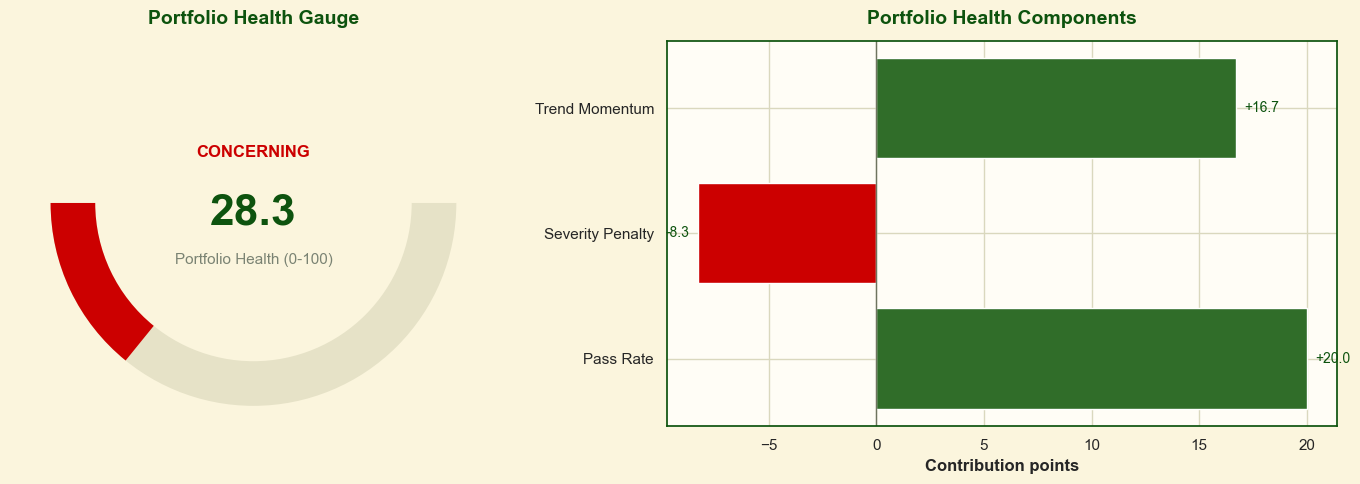

In [41]:
# 6.1 Portfolio health gauge-style chart + component bars.
health_score = portfolio_health["score"]
components_df = pd.DataFrame(portfolio_health["components"])

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.4])

# Gauge-style semicircle
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_aspect("equal")
ax0.axis("off")

# Background semicircle
bg = patches.Wedge((0, 0), 1.0, 180, 360, width=0.22, facecolor="#E6E2C7", edgecolor="none")
ax0.add_patch(bg)

# Score arc
score_angle = 180 + (health_score / 100) * 180
fg = patches.Wedge((0, 0), 1.0, 180, score_angle, width=0.22, facecolor=portfolio_health["verdict_color"], edgecolor="none")
ax0.add_patch(fg)

ax0.text(0, -0.05, f"{health_score:.1f}", ha="center", va="center", fontsize=32, fontweight="bold", color=COLORS["forest_dark"])
ax0.text(0, -0.28, "Portfolio Health (0-100)", ha="center", va="center", fontsize=11, color=COLORS["grey"])
ax0.text(0, 0.25, portfolio_health["verdict"], ha="center", va="center", fontsize=12, fontweight="bold", color=portfolio_health["verdict_color"])
ax0.set_xlim(-1.2, 1.2)
ax0.set_ylim(-1.1, 0.8)
ax0.set_title("Portfolio Health Gauge", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])

# Component contribution bars
ax1 = fig.add_subplot(gs[0, 1])
comp_plot = components_df.copy()
comp_plot["bar_color"] = comp_plot["score"].apply(lambda x: COLORS["forest"] if x >= 0 else COLORS["red"])
ax1.barh(comp_plot["label"], comp_plot["score"], color=comp_plot["bar_color"])
ax1.axvline(0, color="#6E745F", linewidth=1)
ax1.set_title("Portfolio Health Components", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
ax1.set_xlabel("Contribution points")
for i, row in comp_plot.iterrows():
    ax1.text(row["score"] + (0.4 if row["score"] >= 0 else -0.4), i, f"{row['score']:+.1f}", va="center",
             ha="left" if row["score"] >= 0 else "right", fontsize=10, color=COLORS["forest_dark"])

plt.tight_layout()
plt.show()


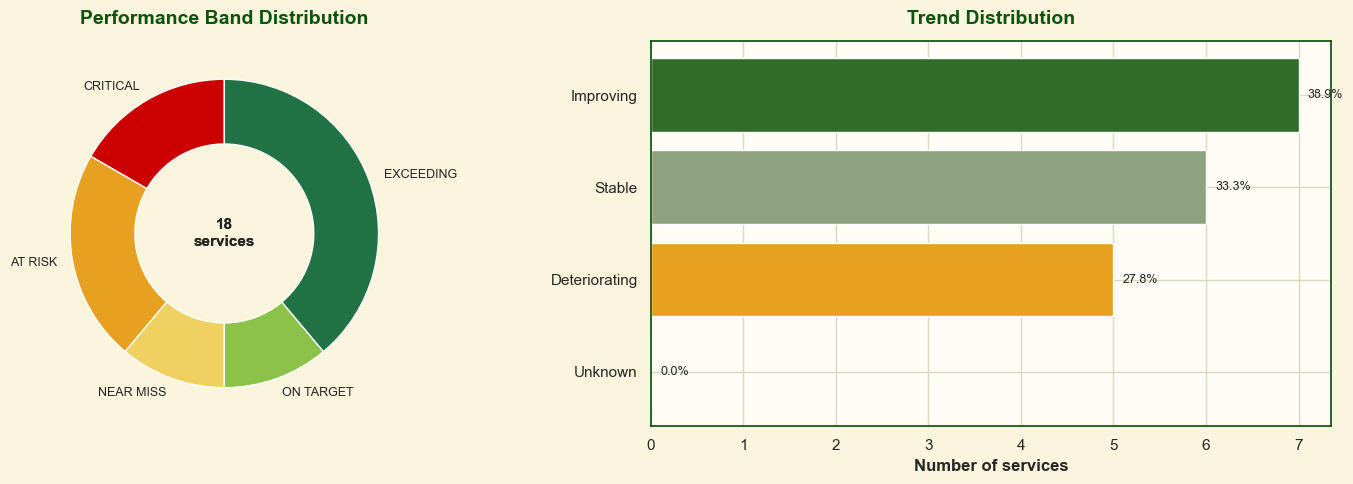

In [42]:
# 6.2 Performance band and trend distribution charts.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Donut for performance bands
band_counts = performance_bands["count"].values
band_labels = performance_bands["band"].values
band_colors = [PERF_BAND_COLOR.get(label, COLORS["grey"]) for label in band_labels]

wedges, texts = axes[0].pie(
    band_counts,
    labels=band_labels,
    colors=band_colors,
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
    textprops={"fontsize": 9},
)
axes[0].set_title("Performance Band Distribution", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
axes[0].text(0, 0, f"{int(performance_bands['count'].sum())}\nservices", ha="center", va="center", fontsize=11, fontweight="bold")
axes[0].text(0, 0, f"{int(performance_bands['count'].sum())}\nservices", ha="center", va="center", fontsize=11, fontweight="bold")

# Trend distribution bars
trend_plot = trend_distribution.sort_values("count", ascending=True)
trend_palette = {
    "Improving": COLORS["forest"],
    "Stable": "#8FA27F",
    "Deteriorating": COLORS["amber"],
    "Unknown": COLORS["grey"],
}
axes[1].barh(trend_plot["label"], trend_plot["count"], color=trend_plot["label"].map(trend_palette))
axes[1].set_title("Trend Distribution", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
axes[1].set_xlabel("Number of services")
for i, row in trend_plot.reset_index(drop=True).iterrows():
    axes[1].text(row["count"] + 0.1, i, f"{row['percentage']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


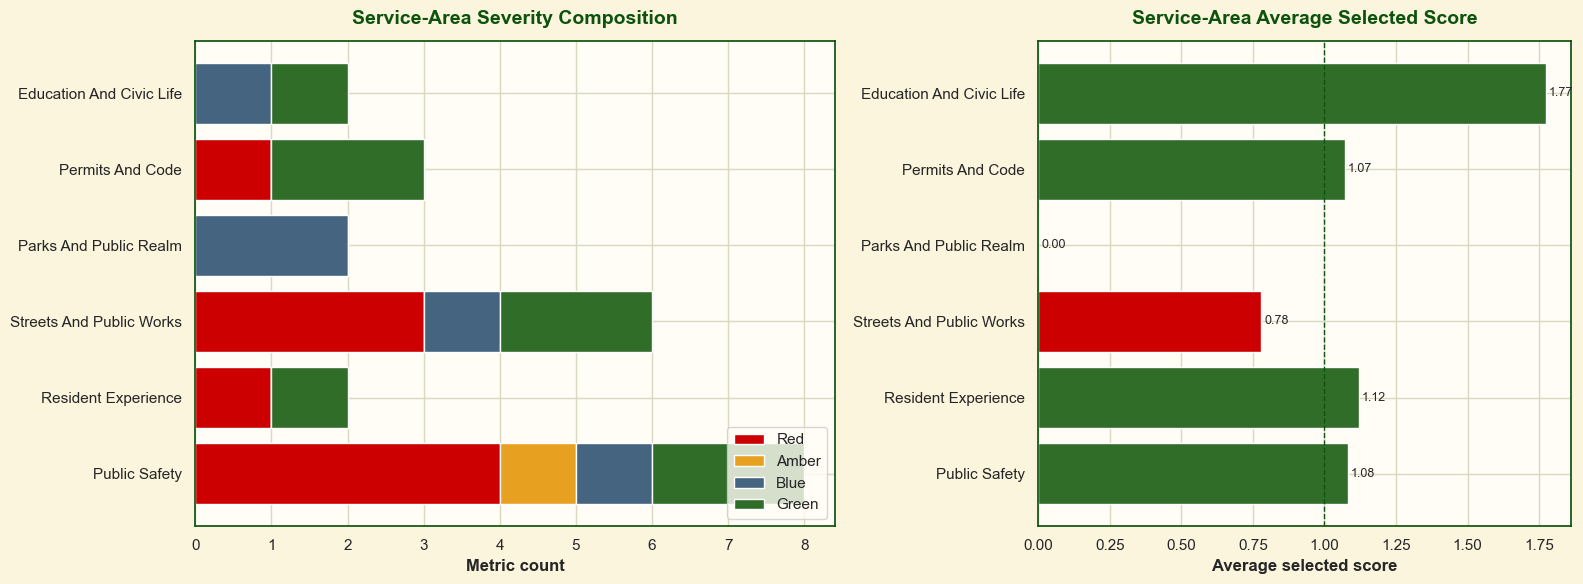

In [43]:
# 6.3 Service-area pressure: stacked severity mix + average score heat bar.
service_plot = service_area_summary.copy()
service_plot = service_plot.sort_values("service_area_order")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.2, 1]})

# Stacked severity bars
left = np.zeros(len(service_plot))
for sev in ["red_count", "amber_count", "blue_count", "green_count"]:
    key = sev.replace("_count", "")
    axes[0].barh(
        service_plot["service_area"],
        service_plot[sev],
        left=left,
        color=SEVERITY_COLOR[key],
        label=key.title(),
    )
    left += service_plot[sev].values

axes[0].set_title("Service-Area Severity Composition", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
axes[0].set_xlabel("Metric count")
axes[0].legend(loc="lower right")

# Average selected score heat-style bars
norm_scores = service_plot["selected_score_average"].fillna(0)
bar_colors = [
    COLORS["forest"] if x >= 1 else (COLORS["amber"] if x >= 0.9 else COLORS["red"])
    for x in norm_scores
]
axes[1].barh(service_plot["service_area"], norm_scores, color=bar_colors)
axes[1].axvline(1.0, color=COLORS["forest_dark"], linestyle="--", linewidth=1)
axes[1].set_title("Service-Area Average Selected Score", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
axes[1].set_xlabel("Average selected score")
for i, value in enumerate(norm_scores):
    axes[1].text(value + 0.01, i, f"{value:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


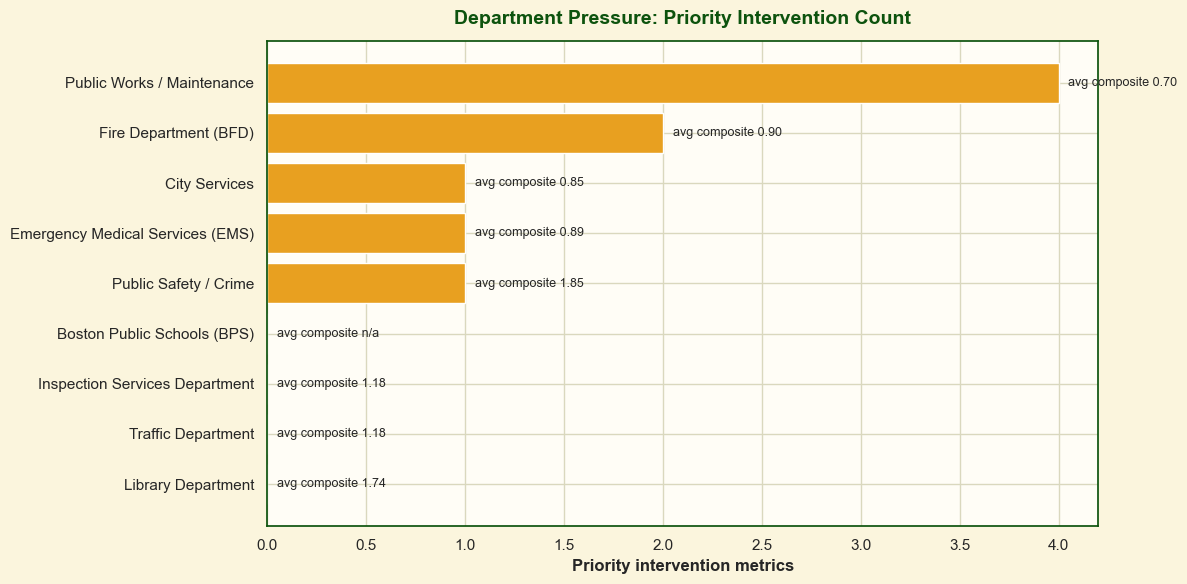

In [44]:
# 6.4 Department pressure bars.
dep_plot = department_summary.sort_values("priority_intervention_count", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    dep_plot["department"],
    dep_plot["priority_intervention_count"],
    color=COLORS["amber"],
)
ax.set_title("Department Pressure: Priority Intervention Count", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
ax.set_xlabel("Priority intervention metrics")

for bar, avg_score in zip(bars, dep_plot["composite_score_average"].fillna(np.nan)):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"avg composite {avg_score:.2f}" if pd.notna(avg_score) else "avg composite n/a",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


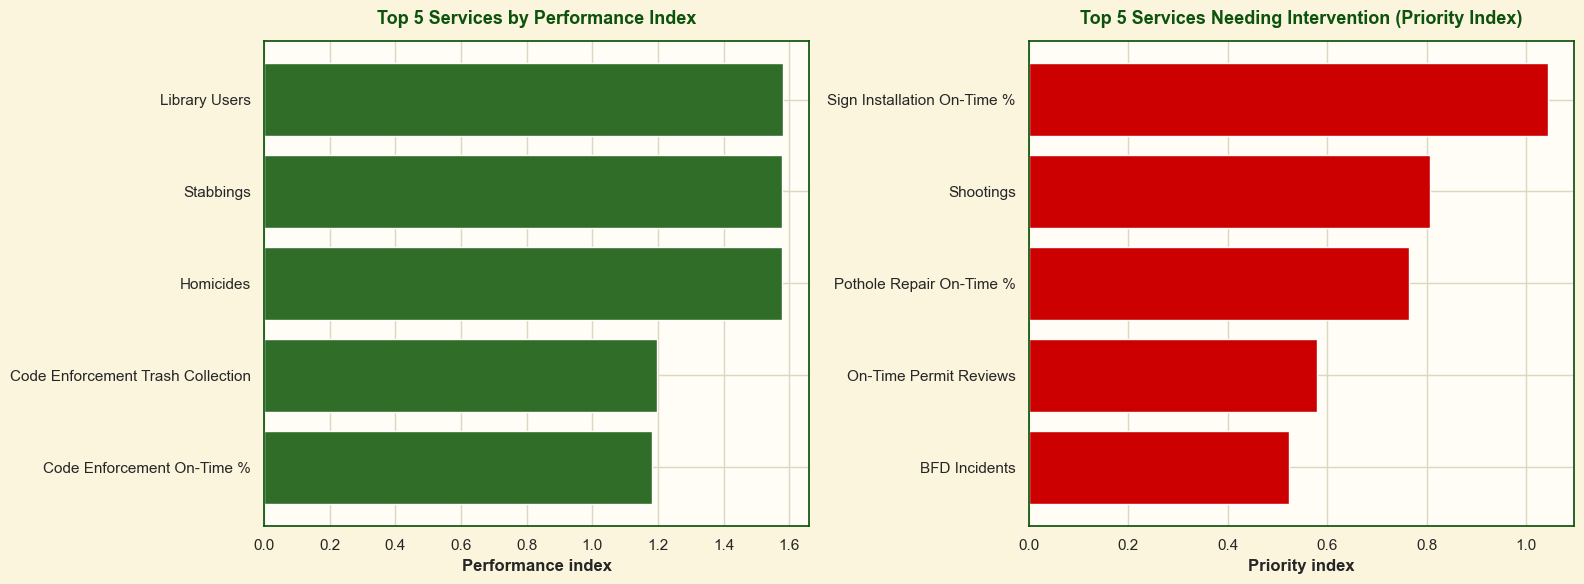

In [45]:
# 6.5 Top 5 and Bottom 5 services (performance and intervention views).
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 5 by performance index
best_plot = best_services.sort_values("performance_index", ascending=True)
axes[0].barh(best_plot["display_name"], best_plot["performance_index"], color=COLORS["forest"])
axes[0].set_title("Top 5 Services by Performance Index", fontsize=13, fontweight="bold", color=COLORS["forest_dark"])
axes[0].set_xlabel("Performance index")

# Bottom 5 by priority index
worst_plot = worst_services.sort_values("priority_index", ascending=True)
axes[1].barh(worst_plot["display_name"], worst_plot["priority_index"], color=COLORS["red"])
axes[1].set_title("Top 5 Services Needing Intervention (Priority Index)", fontsize=13, fontweight="bold", color=COLORS["forest_dark"])
axes[1].set_xlabel("Priority index")

plt.tight_layout()
plt.show()


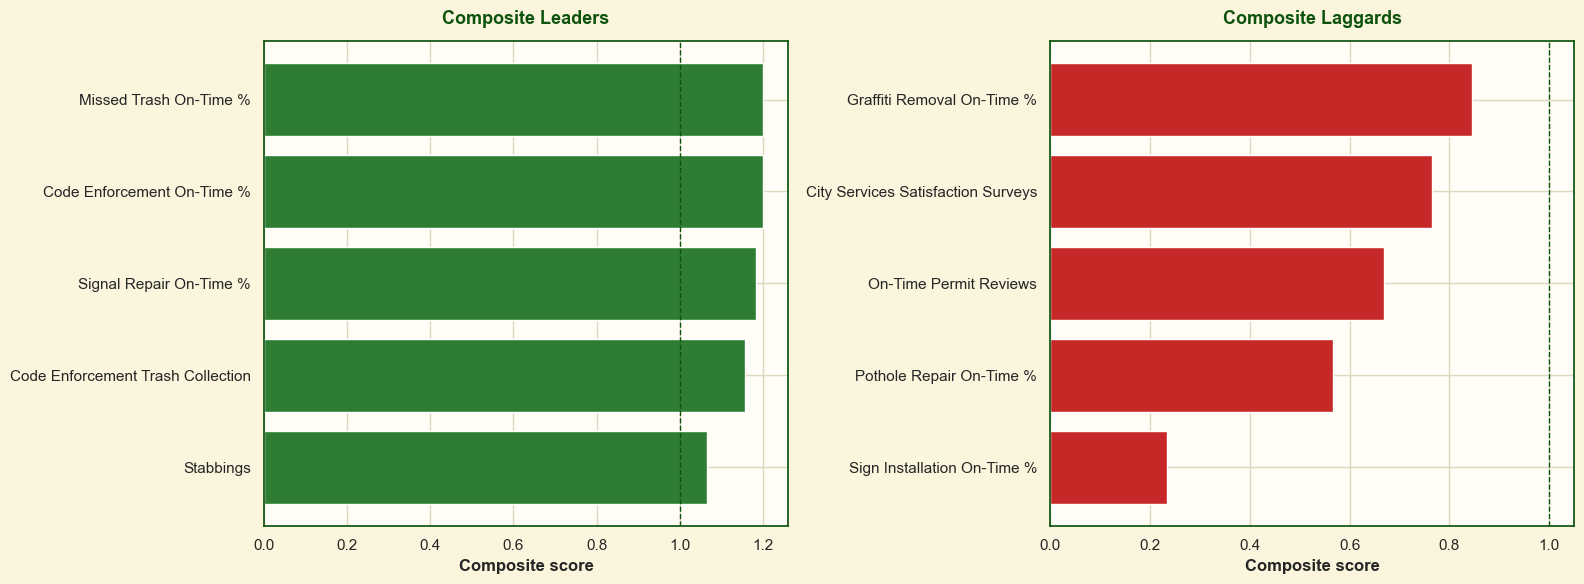

In [46]:
# 6.6 Composite leaders vs laggards.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

leaders_plot = composite_leaders.sort_values("composite_score", ascending=True)
laggards_plot = composite_laggards.sort_values("composite_score", ascending=True)

axes[0].barh(leaders_plot["display_name"], leaders_plot["composite_score"], color="#2E7D32")
axes[0].axvline(1.0, color=COLORS["forest_dark"], linestyle="--", linewidth=1)
axes[0].set_title("Composite Leaders", fontsize=13, fontweight="bold", color=COLORS["forest_dark"])
axes[0].set_xlabel("Composite score")

axes[1].barh(laggards_plot["display_name"], laggards_plot["composite_score"], color="#C62828")
axes[1].axvline(1.0, color=COLORS["forest_dark"], linestyle="--", linewidth=1)
axes[1].set_title("Composite Laggards", fontsize=13, fontweight="bold", color=COLORS["forest_dark"])
axes[1].set_xlabel("Composite score")

plt.tight_layout()
plt.show()


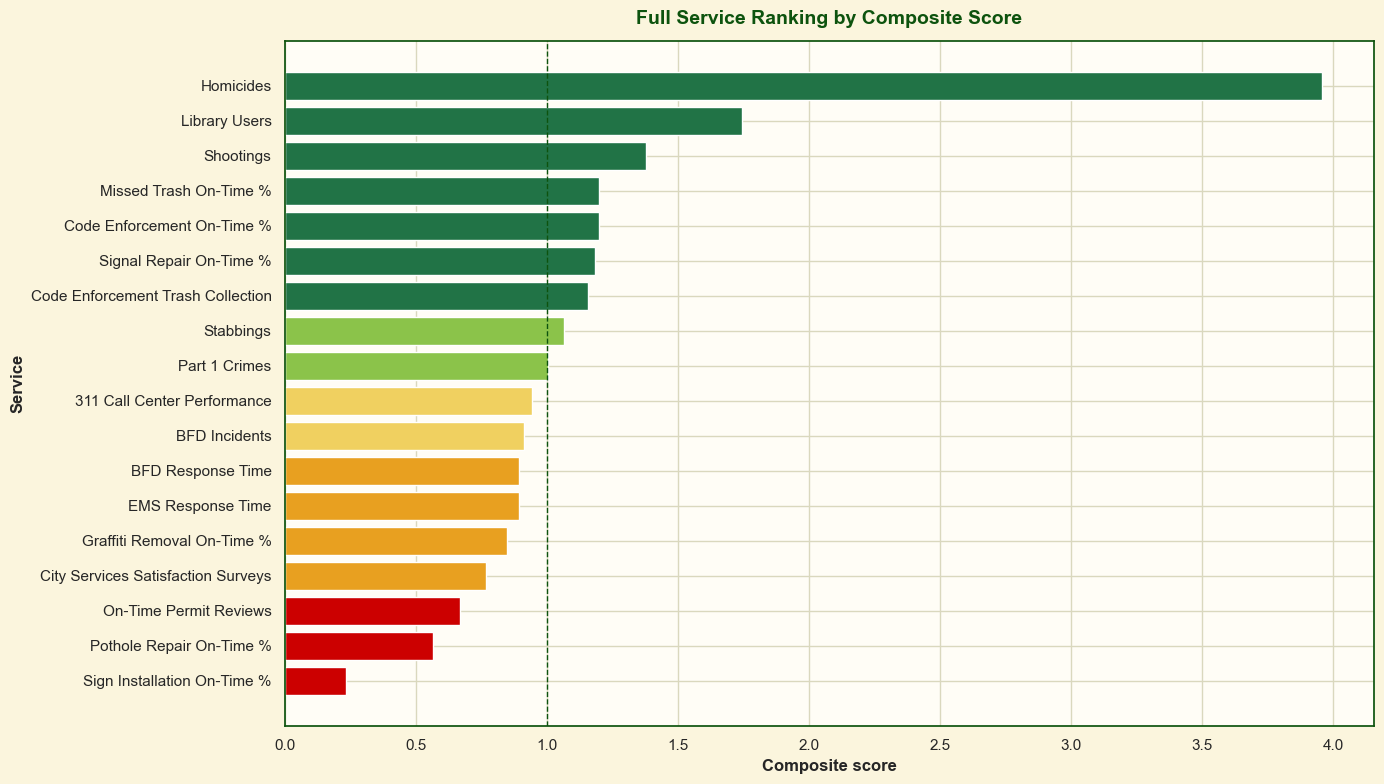

In [47]:
# 6.7 Full service ranking bar chart.
ranking_plot = full_service_ranking.copy()
ranking_plot["rank"] = np.arange(1, len(ranking_plot) + 1)
ranking_plot = ranking_plot.sort_values("composite_score", ascending=True)

plt.figure(figsize=(14, 8))
bar_colors = [PERF_BAND_COLOR.get(band, COLORS["grey"]) for band in ranking_plot["perf_band"]]
plt.barh(ranking_plot["display_name"], ranking_plot["composite_score"], color=bar_colors)
plt.axvline(1.0, color=COLORS["forest_dark"], linestyle="--", linewidth=1)
plt.title("Full Service Ranking by Composite Score", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
plt.xlabel("Composite score")
plt.ylabel("Service")
plt.tight_layout()
plt.show()


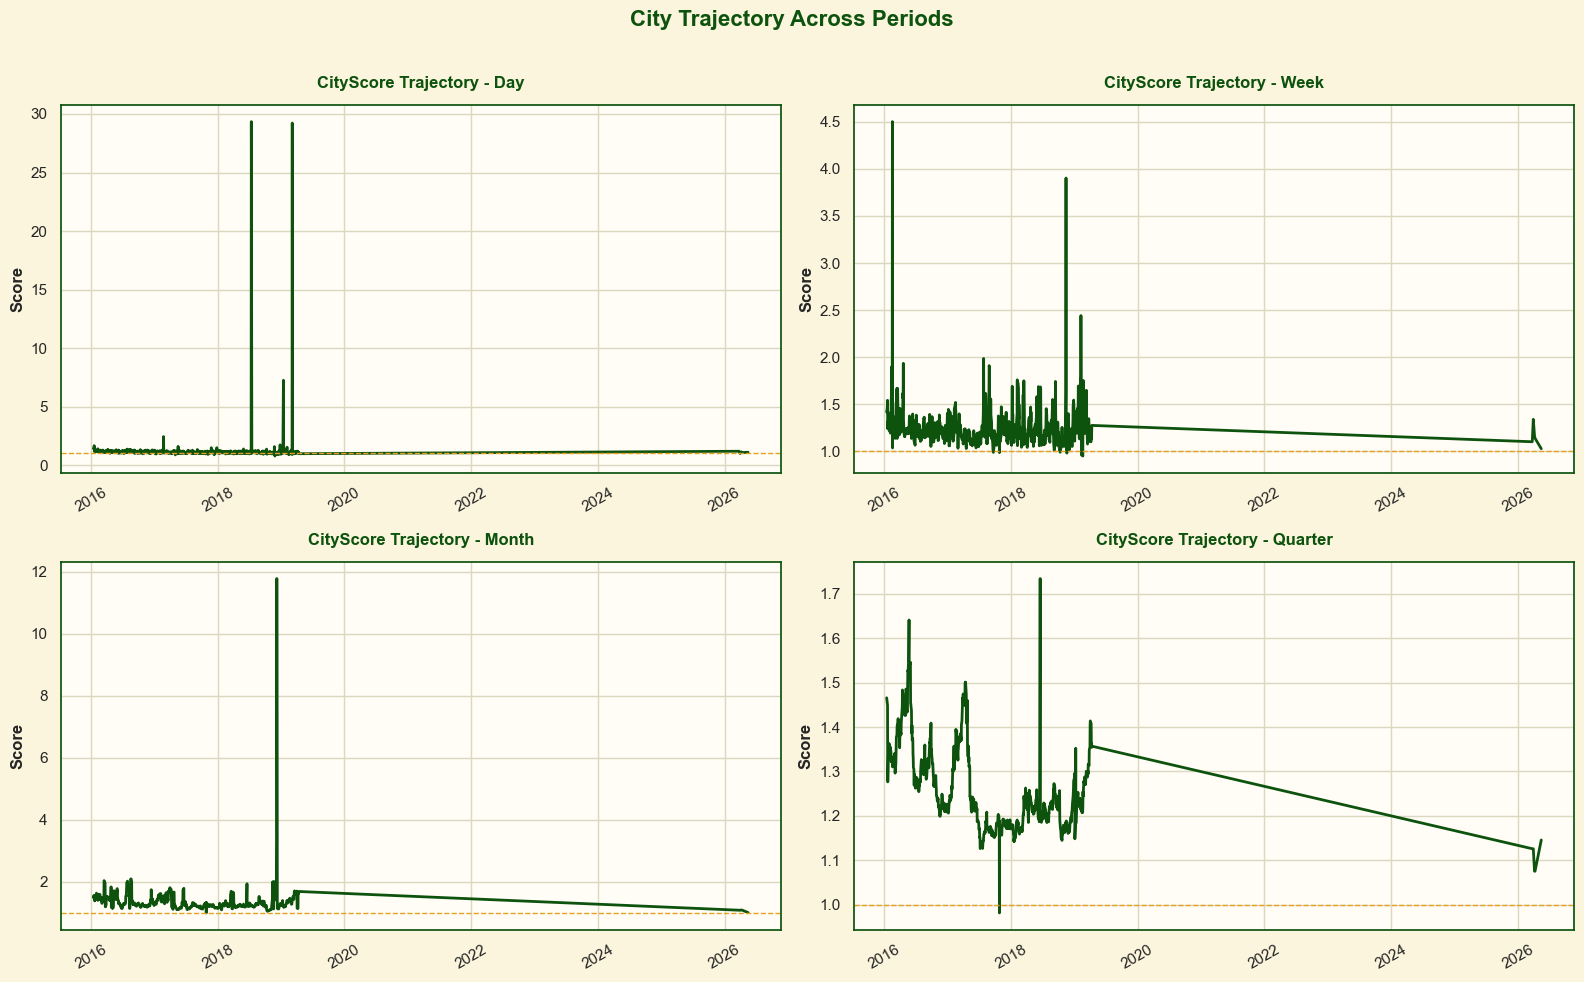

In [48]:
# 6.8 Day/Week/Month/Quarter city trajectory charts.
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
period_order = ["day", "week", "month", "quarter"]

for ax, period in zip(axes.flatten(), period_order):
    subset = city_score_history[city_score_history["period_type"] == period].sort_values("as_of_date")
    ax.plot(subset["as_of_date"], subset["score"], color=COLORS["forest_dark"], linewidth=2)
    ax.axhline(1.0, color=COLORS["amber"], linestyle="--", linewidth=1)
    ax.set_title(f"CityScore Trajectory - {period.title()}", fontsize=12, fontweight="bold", color=COLORS["forest_dark"])
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("City Trajectory Across Periods", fontsize=16, fontweight="bold", color=COLORS["forest_dark"])
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


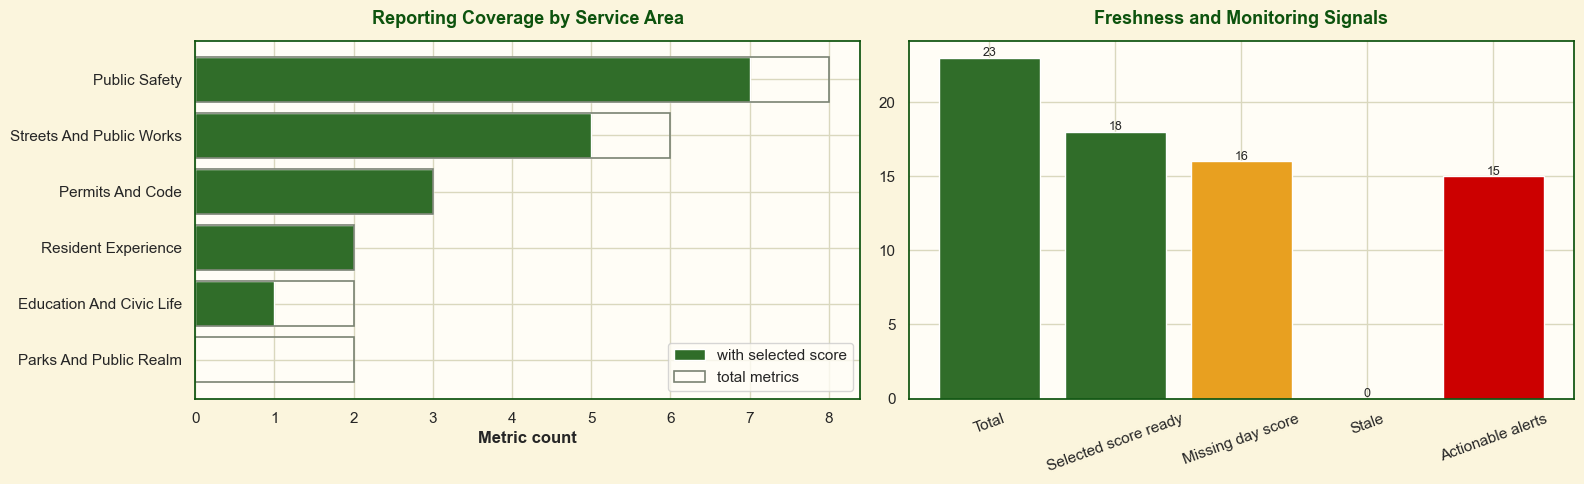

In [49]:
# 6.9 Freshness and reporting coverage chart.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Coverage by service area
coverage_plot = freshness_coverage.sort_values("metrics_with_selected_score", ascending=True)
axes[0].barh(
    coverage_plot["service_area"],
    coverage_plot["metrics_with_selected_score"],
    color=COLORS["forest"],
    label="with selected score",
)
axes[0].barh(
    coverage_plot["service_area"],
    coverage_plot["total_metrics"],
    color="none",
    edgecolor=COLORS["grey"],
    linewidth=1.2,
    label="total metrics",
)
axes[0].set_title("Reporting Coverage by Service Area", fontsize=13, fontweight="bold", color=COLORS["forest_dark"])
axes[0].set_xlabel("Metric count")
axes[0].legend()

# Freshness KPI bars
fresh_metrics = pd.DataFrame([
    {"metric": "Total", "value": freshness_summary["metrics_total"]},
    {"metric": "Selected score ready", "value": freshness_summary["metrics_with_selected_score"]},
    {"metric": "Missing day score", "value": freshness_summary["metrics_missing_day_score"]},
    {"metric": "Stale", "value": freshness_summary["stale_metrics"]},
    {"metric": "Actionable alerts", "value": freshness_summary["actionable_alerts"]},
])

axes[1].bar(fresh_metrics["metric"], fresh_metrics["value"], color=[COLORS["forest"], COLORS["forest"], COLORS["amber"], COLORS["blue"], COLORS["red"]])
axes[1].set_title("Freshness and Monitoring Signals", fontsize=13, fontweight="bold", color=COLORS["forest_dark"])
axes[1].tick_params(axis="x", rotation=20)
for i, val in enumerate(fresh_metrics["value"]):
    axes[1].text(i, val + 0.1, str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## 7) Architecture and Data Flow

The following diagram and tables explain how this EDA layer maps to the deployed backend and dashboard.


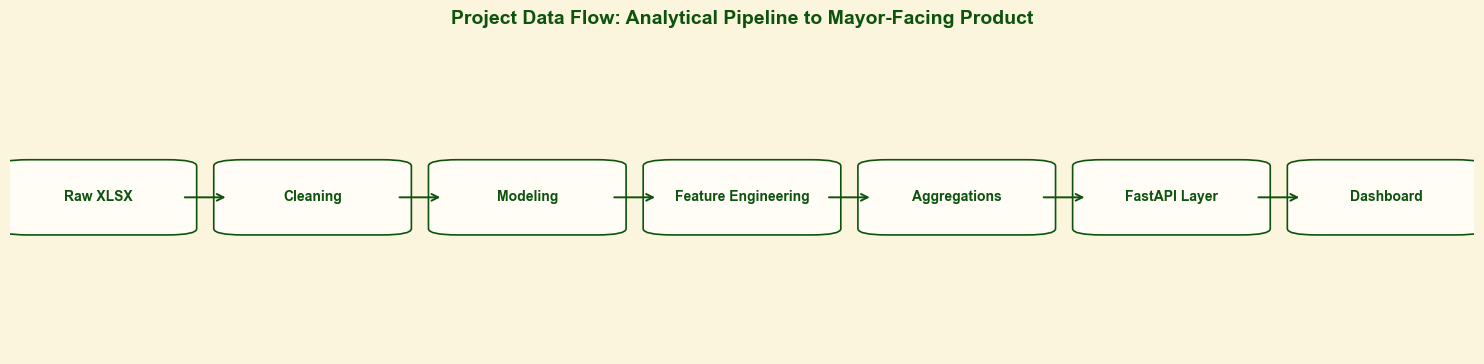

In [50]:
# Visual flow diagram: Raw -> Cleaning -> Modeling -> Features -> Aggregations -> API -> Dashboard
fig, ax = plt.subplots(figsize=(15, 3.8))
ax.axis("off")

steps = [
    "Raw XLSX", "Cleaning", "Modeling", "Feature Engineering",
    "Aggregations", "FastAPI Layer", "Dashboard",
]

x_positions = np.linspace(0.06, 0.94, len(steps))
y = 0.5
box_w, box_h = 0.115, 0.22

for i, (x, label) in enumerate(zip(x_positions, steps)):
    rect = patches.FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=1.2,
        edgecolor=COLORS["forest_dark"],
        facecolor="#FFFDF6",
    )
    ax.add_patch(rect)
    ax.text(x, y, label, ha="center", va="center", fontsize=10, fontweight="bold", color=COLORS["forest_dark"])

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - box_w / 2, y),
            xytext=(x + box_w / 2, y),
            arrowprops=dict(arrowstyle="->", color=COLORS["forest_dark"], lw=1.4),
        )

ax.set_title("Project Data Flow: Analytical Pipeline to Mayor-Facing Product", fontsize=14, fontweight="bold", color=COLORS["forest_dark"])
plt.tight_layout()
plt.show()


In [51]:
# Artifact map: notebook outputs and product artifacts.
artifact_map = pd.DataFrame([
    {"artifact": "metric_master", "description": "Metric dictionary with service area, owner, cadence, and definition"},
    {"artifact": "metric_history_long", "description": "Metric-level time series by period and date"},
    {"artifact": "city_score_history", "description": "Citywide day/week/month/quarter trajectories"},
    {"artifact": "latest_metric_snapshot", "description": "Latest per-metric view with derived features and alerts"},
    {"artifact": "mayor_alerts", "description": "Non-green alert list sorted by severity and urgency"},
    {"artifact": "service_area_summary", "description": "Service-area score averages and severity composition"},
    {"artifact": "executive_brief", "description": "Headline diagnosis, rankings, and recommendation payload"},
])

artifact_map


,artifact,description
0,metric_master,"Metric dictionary with service area, owner, ca..."
1,metric_history_long,Metric-level time series by period and date
2,city_score_history,Citywide day/week/month/quarter trajectories
3,latest_metric_snapshot,Latest per-metric view with derived features a...
4,mayor_alerts,Non-green alert list sorted by severity and ur...
5,service_area_summary,Service-area score averages and severity compo...
6,executive_brief,"Headline diagnosis, rankings, and recommendati..."


In [52]:
# API endpoint map used by the dashboard frontend.
api_map = pd.DataFrame([
    {"endpoint": "/api/v1/pipeline/status", "purpose": "Pipeline refresh timestamp and artifact counts"},
    {"endpoint": "/api/v1/pipeline/refresh", "purpose": "On-demand ingestion/refresh"},
    {"endpoint": "/api/v1/dashboard/overview", "purpose": "Top cards, critical alerts, and service scorecards"},
    {"endpoint": "/api/v1/dashboard/executive-brief", "purpose": "Executive diagnosis payload (headline, rankings, actions)"},
    {"endpoint": "/api/v1/dashboard/city-history", "purpose": "City trajectory for day/week/month/quarter"},
    {"endpoint": "/api/v1/dashboard/alerts", "purpose": "Current alert/watchlist records"},
    {"endpoint": "/api/v1/dashboard/service-areas", "purpose": "Service-area pressure summary"},
    {"endpoint": "/api/v1/dashboard/freshness", "purpose": "Coverage, stale metrics, and data completeness"},
    {"endpoint": "/api/v1/metrics", "purpose": "Metric catalog and quick filtering"},
    {"endpoint": "/api/v1/metrics/{metric_name}", "purpose": "Metric detail payload"},
    {"endpoint": "/api/v1/metrics/{metric_name}/history", "purpose": "Metric trend series for drill-down"},
])

api_map


,endpoint,purpose
0,/api/v1/pipeline/status,Pipeline refresh timestamp and artifact counts
1,/api/v1/pipeline/refresh,On-demand ingestion/refresh
2,/api/v1/dashboard/overview,"Top cards, critical alerts, and service scorec..."
3,/api/v1/dashboard/executive-brief,"Executive diagnosis payload (headline, ranking..."
4,/api/v1/dashboard/city-history,City trajectory for day/week/month/quarter
5,/api/v1/dashboard/alerts,Current alert/watchlist records
6,/api/v1/dashboard/service-areas,Service-area pressure summary
7,/api/v1/dashboard/freshness,"Coverage, stale metrics, and data completeness"
8,/api/v1/metrics,Metric catalog and quick filtering
9,/api/v1/metrics/{metric_name},Metric detail payload


## 8) Findings and Limitations

The outputs below summarize the current snapshot in quantitative terms and document important caveats.


In [53]:
# Key findings from the current build.
above_target_rate = float((ranked_metrics["selected_score"] >= 1).mean()) if len(ranked_metrics) else np.nan
priority_count = int((latest_metric_snapshot["consulting_bucket"] == "Priority Intervention").sum())
strongest_area = service_area_summary.sort_values("selected_score_average", ascending=False).iloc[0]["service_area"]
weakest_area = service_area_summary.sort_values("selected_score_average", ascending=True).iloc[0]["service_area"]

print("Key Findings")
print("------------")
print(f"- Services in scope: {len(latest_metric_snapshot)}")
print(f"- Services with selected score: {len(ranked_metrics)}")
print(f"- Share above target: {above_target_rate:.1%}")
print(f"- Portfolio health score: {portfolio_health['score']} ({portfolio_health['verdict']})")
print(f"- Priority intervention count: {priority_count}")
print(f"- Strongest service area by average selected score: {strongest_area}")
print(f"- Weakest service area by average selected score: {weakest_area}")
print(f"- Metric history rows: {len(metric_history_long):,}")
print(f"- City history rows: {len(city_score_history):,}")


Key Findings
------------
- Services in scope: 23
- Services with selected score: 18
- Share above target: 50.0%
- Portfolio health score: 28.3 (CONCERNING)
- Priority intervention count: 9
- Strongest service area by average selected score: Education And Civic Life
- Weakest service area by average selected score: Streets And Public Works
- Metric history rows: 70,661
- City history rows: 3,396


In [54]:
# Caveats and limitations directly tied to data behavior.
min_hist_date = metric_history_long["as_of_date"].min()
max_hist_date = metric_history_long["as_of_date"].max()
current_min = cleaned_frames["current_full_metrics"]["score_calculated_ts"].min()
current_max = cleaned_frames["current_full_metrics"]["score_calculated_ts"].max()

limitations = [
    "Historical report spans earlier years, while current snapshot dates are recent; blending requires careful interpretation.",
    "Selected-period logic prioritizes day > week > month > quarter for current state, while composite score prioritizes quarter > month > week for ranking stability.",
    "Some metrics have sparse updates and appear as Data Gap; missing data is tracked separately from underperformance.",
    "Rolling baselines use available history; structural changes in source systems can influence baseline comparability.",
]

print("Date Coverage Context")
print("---------------------")
print(f"- Metric history range: {min_hist_date} to {max_hist_date}")
print(f"- Current full snapshot range: {current_min} to {current_max}")

print("\nLimitations")
print("-----------")
for item in limitations:
    print(f"- {item}")


Date Coverage Context
---------------------
- Metric history range: 2016-01-15 00:00:00 to 2026-05-16 00:00:00
- Current full snapshot range: 2026-03-25 11:24:48.813000 to 2026-05-16 07:20:18.724000

Limitations
-----------
- Historical report spans earlier years, while current snapshot dates are recent; blending requires careful interpretation.
- Selected-period logic prioritizes day > week > month > quarter for current state, while composite score prioritizes quarter > month > week for ranking stability.
- Some metrics have sparse updates and appear as Data Gap; missing data is tracked separately from underperformance.
- Rolling baselines use available history; structural changes in source systems can influence baseline comparability.


## 9) Validation Checks and Optional Parity with Saved Artifacts

This section validates run integrity and optionally compares core outputs with saved files in `aggregated data/`.


In [55]:
# Core run integrity checks from the test plan.
assert all(path.exists() for path in SOURCE_FILES.values()), "One or more required source files are missing"
assert len(metric_master) > 0, "metric_master should not be empty"
assert len(metric_history_long) > 0, "metric_history_long should not be empty"
assert len(city_score_history) > 0, "city_score_history should not be empty"
assert len(latest_metric_snapshot) > 0, "latest_metric_snapshot should not be empty"
assert len(best_services) == 5, "best_services should contain 5 rows"
assert len(worst_services) == 5, "worst_services should contain 5 rows"

assert metric_history_long["as_of_date"].min() <= metric_history_long["as_of_date"].max()
assert city_score_history["as_of_date"].min() <= city_score_history["as_of_date"].max()

print("All core validation checks passed.")


All core validation checks passed.


In [56]:
# Optional parity checks against saved aggregated outputs (if available).
parity_report = []

if (AGG_DIR / "metric_master.csv").exists():
    mm_saved = pd.read_csv(AGG_DIR / "metric_master.csv")
    parity_report.append({
        "check": "metric_master_row_count",
        "notebook": len(metric_master),
        "saved": len(mm_saved),
        "match": len(metric_master) == len(mm_saved),
    })

if (AGG_DIR / "metric_history_long.csv").exists():
    mh_saved = pd.read_csv(AGG_DIR / "metric_history_long.csv")
    parity_report.append({
        "check": "metric_history_long_row_count",
        "notebook": len(metric_history_long),
        "saved": len(mh_saved),
        "match": len(metric_history_long) == len(mh_saved),
    })

if (AGG_DIR / "latest_metric_snapshot.csv").exists():
    ls_saved = pd.read_csv(AGG_DIR / "latest_metric_snapshot.csv")
    parity_report.append({
        "check": "latest_metric_snapshot_row_count",
        "notebook": len(latest_metric_snapshot),
        "saved": len(ls_saved),
        "match": len(latest_metric_snapshot) == len(ls_saved),
    })

if (AGG_DIR / "executive_brief.json").exists():
    brief_saved = json.loads((AGG_DIR / "executive_brief.json").read_text())
    saved_status = brief_saved.get("headline_status", None)
    notebook_status = (
        "healthy" if portfolio_health["verdict"] == "HEALTHY"
        else "mixed" if portfolio_health["verdict"] == "MIXED"
        else "concerning"
    )
    parity_report.append({
        "check": "executive_headline_status",
        "notebook": notebook_status,
        "saved": saved_status,
        "match": notebook_status == saved_status,
    })

if parity_report:
    pd.DataFrame(parity_report)
else:
    print("No saved aggregated artifacts found for parity checks.")


## 10) Next Iteration Ideas

- Replace file-based daily refresh with upload-based ingestion (API or object storage).
- Add explicit cadence calendar by metric to improve stale-data interpretation.
- Add trend-break detection to separate temporary spikes from persistent deterioration.
- Add automated notebook-to-dashboard parity tests in CI.
